# Exploratory Data Analysis (EDA)
---
## Tasks done in this notebook:
- Data Loading and First look 
- Data Quality Visualization 
- Target Variable Distribution 
- Univariate Analysis for Numerical features 
- Univariate Analysis for Categorical features
- Bivariate Analysis for Numerical features vs Target feature 
- Bivariate Analysis for Categorical features vs Target feature
- Correlation Matrix for Numerical features
- Time Based patterns to track transaction throughout the full day 
- Amount Analysis deep dive
- Velocity and Behavior Signals
- Device Trust and Location Signals
- Demographic Insight using the cardholder age
- Interaction Exploration 
- EDA Summary and Hypotheses

In [66]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates
import seaborn as sns

### Data Loading and First Look

In [67]:
credit_data_df = pd.read_csv('../data/processed/credit_card_fraud_10k_cleaned.csv')
head = credit_data_df.head()
shape = credit_data_df.shape
print("Head of the DataFrame:")
print(head)
print("\nShape of the DataFrame:")
print(shape)
print("\nInfo about the DataFrame:")
info = credit_data_df.info()


Head of the DataFrame:
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                66.0   
1                    1                  0                87.0   
2                    0                  0                49.0   
3                    0                  1                72.0   
4                    0                  0                79.0   

   velocity_last_24h  cardholder_age  is_fraud  
0                3.0              40         0  
1                1.0              64         0  
2                1.0              61         0  

### Data Quality Visualization

Data Quality Visualizations:


C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\1903647771.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2, 0].boxplot(


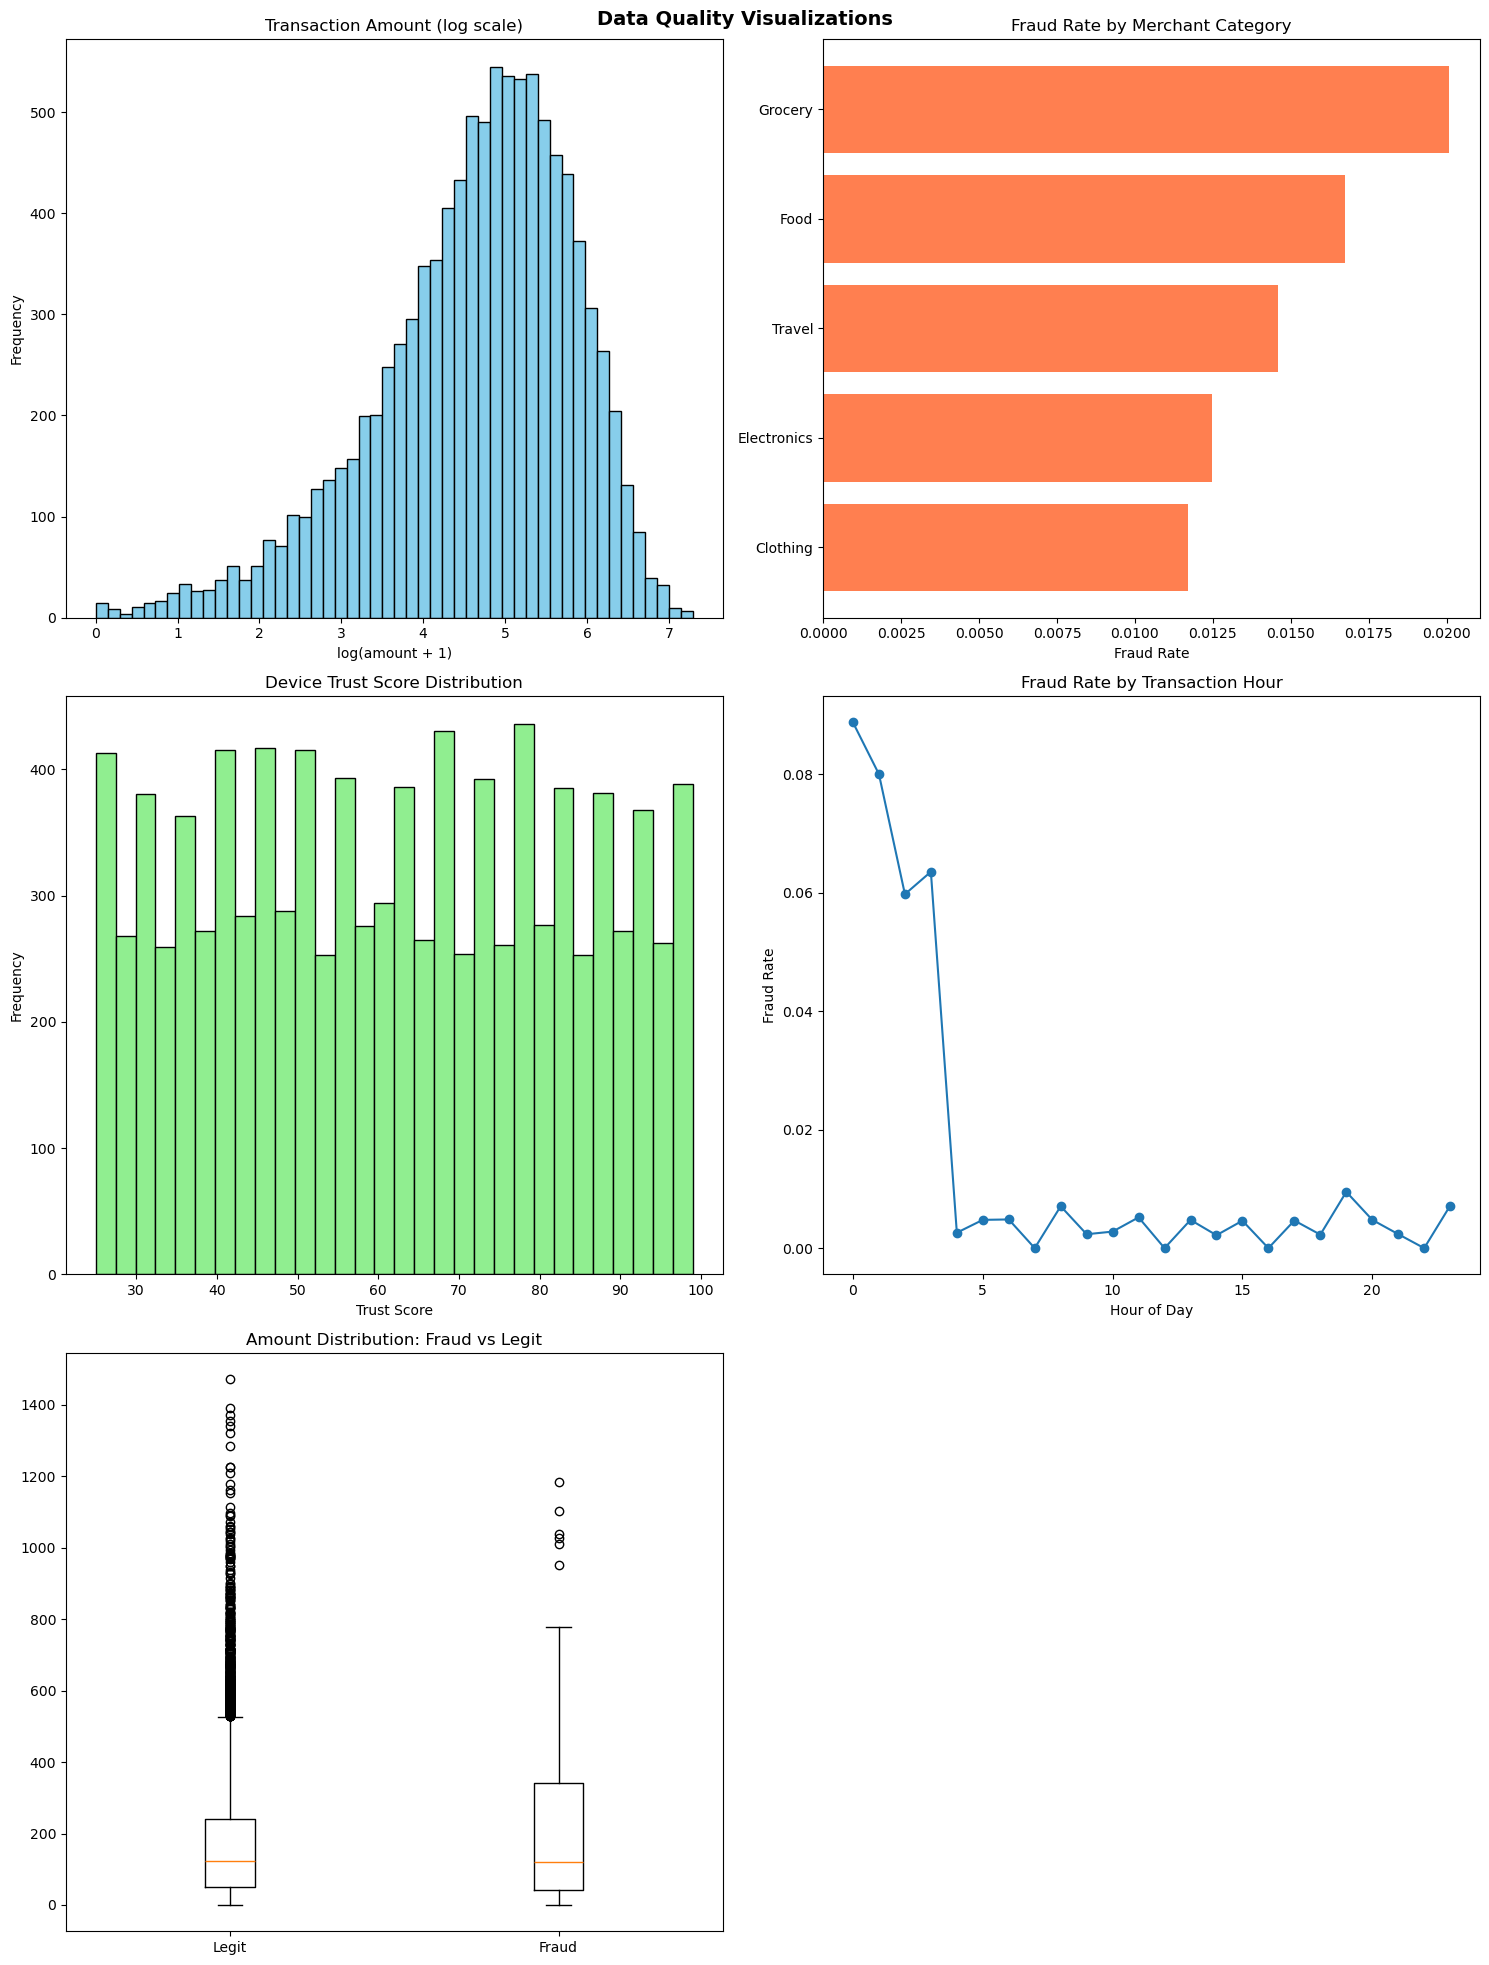

In [68]:
print("Data Quality Visualizations:")
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
fig.suptitle('Data Quality Visualizations', fontsize=14, fontweight='bold')
# Amount distribution (log scale for better visibility)
axes[0, 0].hist(
    np.log1p(credit_data_df['amount']), 
    bins=50, 
    edgecolor='black', 
    color='skyblue'
    )
axes[0, 0].set_title('Transaction Amount (log scale)')
axes[0, 0].set_xlabel('log(amount + 1)')
axes[0, 0].set_ylabel('Frequency')
# Fraud by merchant category
fraud_by_category = credit_data_df.groupby('merchant_category')['is_fraud'].mean().sort_values()
axes[0, 1].barh(
    fraud_by_category.index, 
    fraud_by_category.values, 
    color='coral'
    )
axes[0, 1].set_title('Fraud Rate by Merchant Category')
axes[0, 1].set_xlabel('Fraud Rate')
# Device trust score distribution
axes[1, 0].hist(
    credit_data_df['device_trust_score'],
    bins=30, 
    edgecolor='black', 
    color='lightgreen'
    )
axes[1, 0].set_title('Device Trust Score Distribution')
axes[1, 0].set_xlabel('Trust Score')
axes[1, 0].set_ylabel('Frequency')
# Transaction hour pattern
hourly_fraud = credit_data_df.groupby('transaction_hour')['is_fraud'].mean()
axes[1, 1].plot(
    hourly_fraud.index, 
    hourly_fraud.values, 
    marker='o'
    )
axes[1, 1].set_title('Fraud Rate by Transaction Hour')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Fraud Rate')
# Check for extreme outliers in amount
axes[2, 0].boxplot(
    [credit_data_df[credit_data_df['is_fraud']==0]['amount'], 
    credit_data_df[credit_data_df['is_fraud']==1]['amount']], 
    labels=['Legit', 'Fraud']
    )
axes[2, 0].set_title('Amount Distribution: Fraud vs Legit')

axes[2, 1].axis('off')  
plt.tight_layout()
plt.show()

### Target Variable Distribution


Fraud vs Legitimate Transaction Counts:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Percentage of Fraudulent Transactions: 1.51%
Percentage of Legitimate Transactions: 98.49%


C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\535049719.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


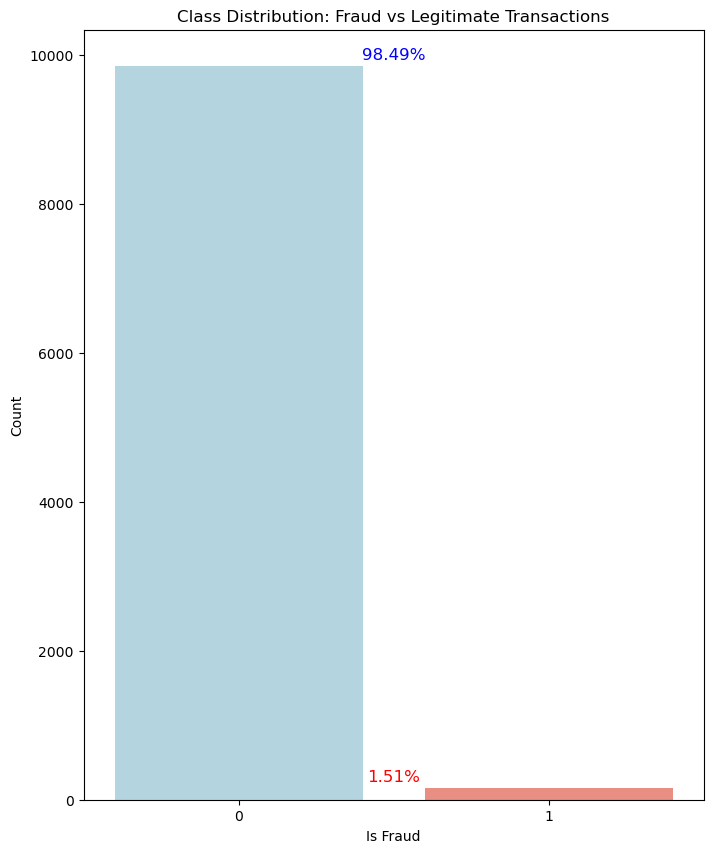

In [69]:
fraud_counts = credit_data_df['is_fraud'].value_counts()
print("\nFraud vs Legitimate Transaction Counts:")
print(fraud_counts)
fraud_percentage = credit_data_df['is_fraud'].mean() * 100
print(f"\nPercentage of Fraudulent Transactions: {fraud_percentage:.2f}%")  
legit_percentage = 100 - fraud_percentage
print(f"Percentage of Legitimate Transactions: {legit_percentage:.2f}%")

plt.figure(figsize=(8, 10))
sns.countplot(
    x='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon']
    )
plt.title('Class Distribution: Fraud vs Legitimate Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.text(
    0.5, 
    fraud_counts[1] + 50, 
    f'{fraud_percentage:.2f}%', 
    ha='center', 
    va='bottom', 
    fontsize=12, 
    color='red'
    )
plt.text(
    0.5, 
    fraud_counts[0] + 50, 
    f'{legit_percentage:.2f}%', 
    ha='center', 
    va='bottom', 
    fontsize=12, 
    color='blue'
    )
plt.show()


### Univariate Analysis – Numerical Features


Histograms of Numerical Features:


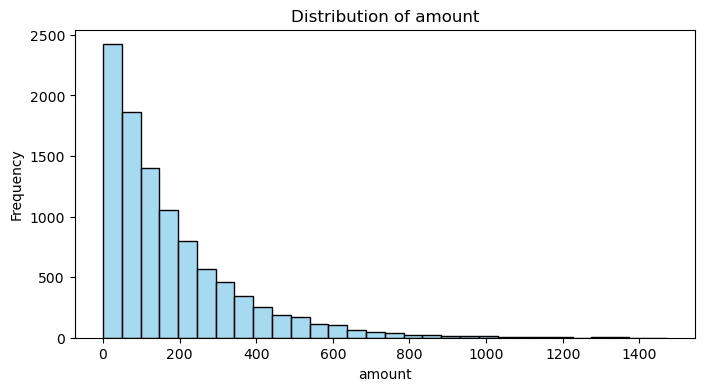

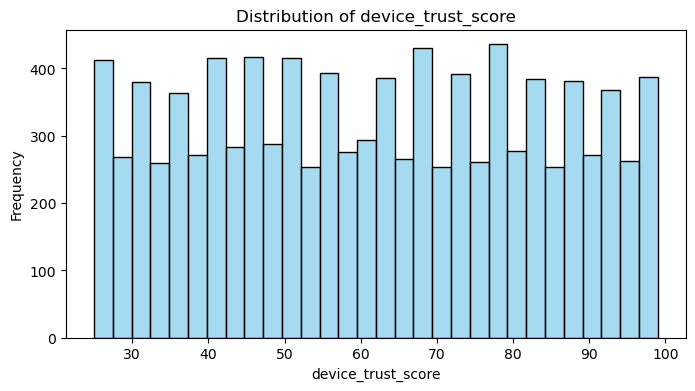

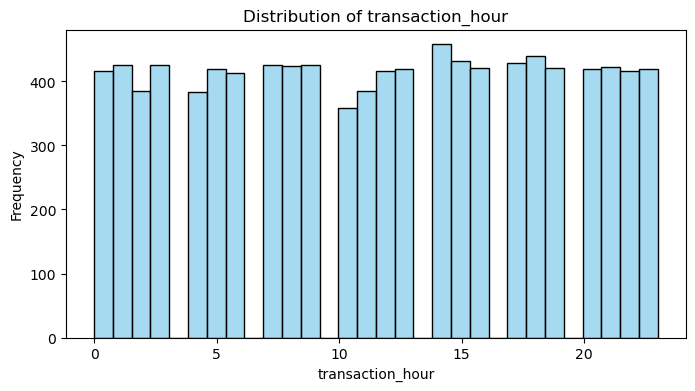

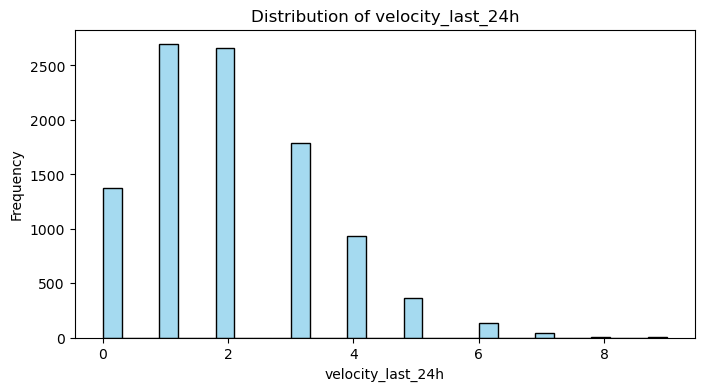

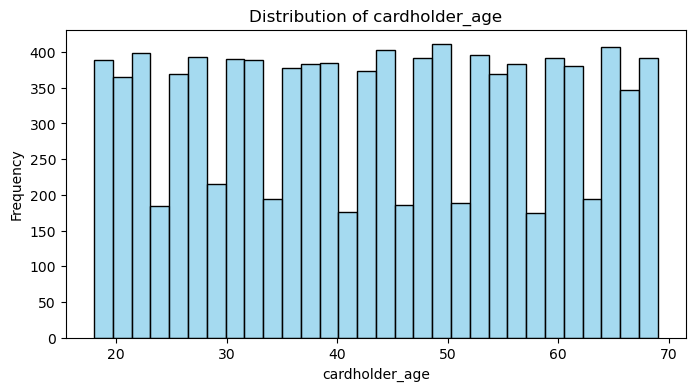


KDE Plots of Numerical Features:


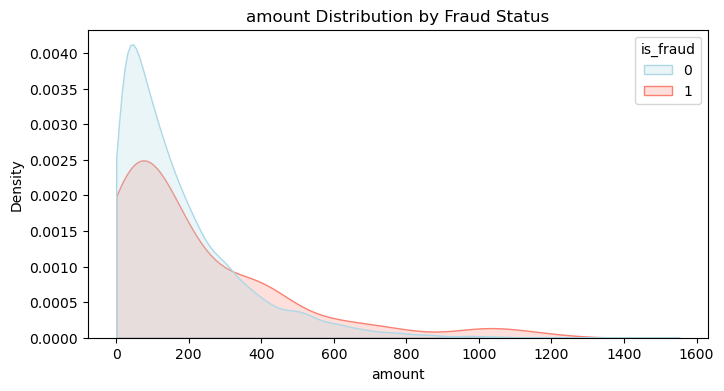

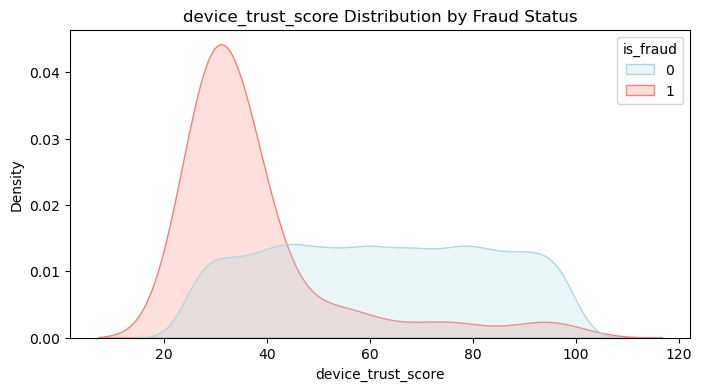

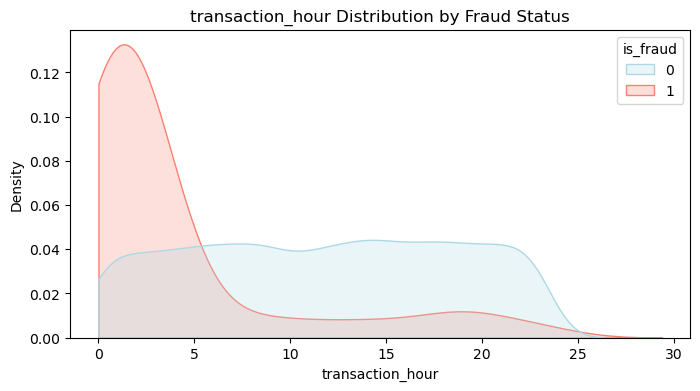

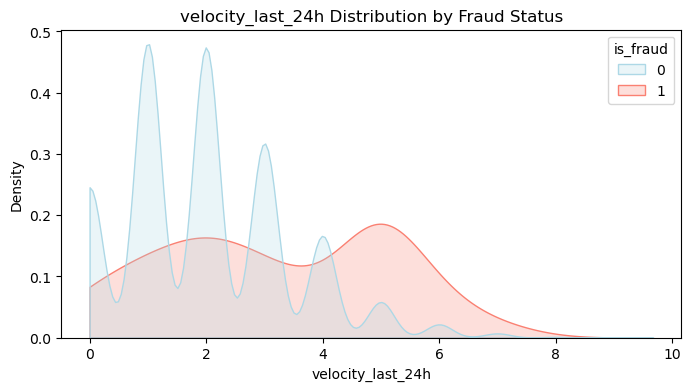

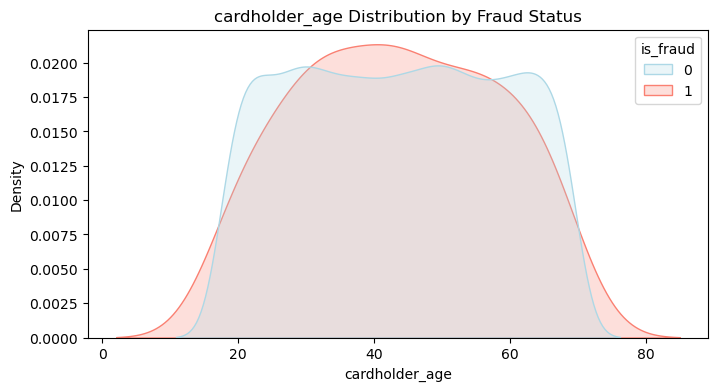


Box Plots of Numerical Features:


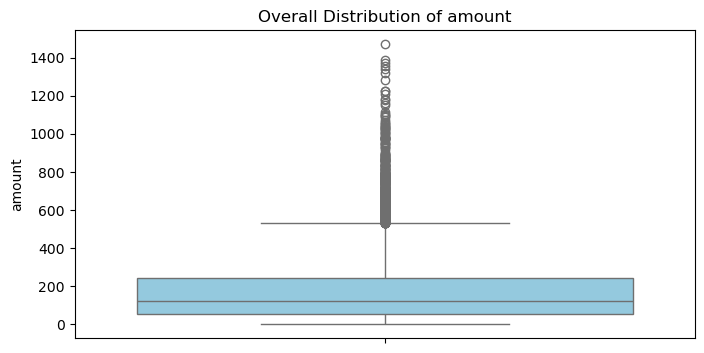

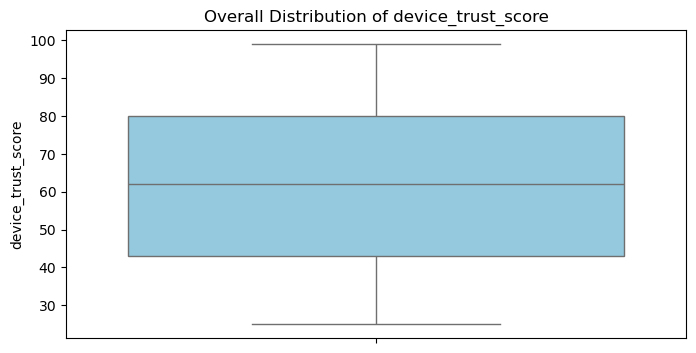

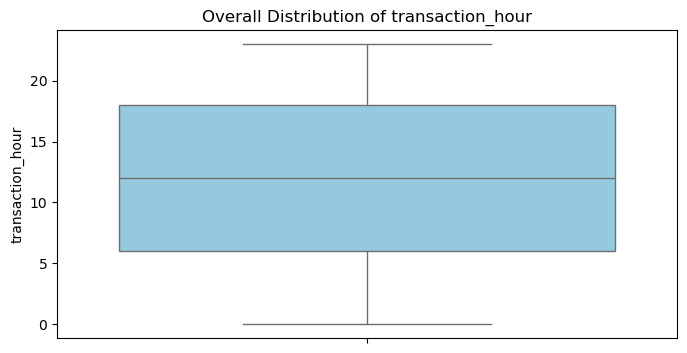

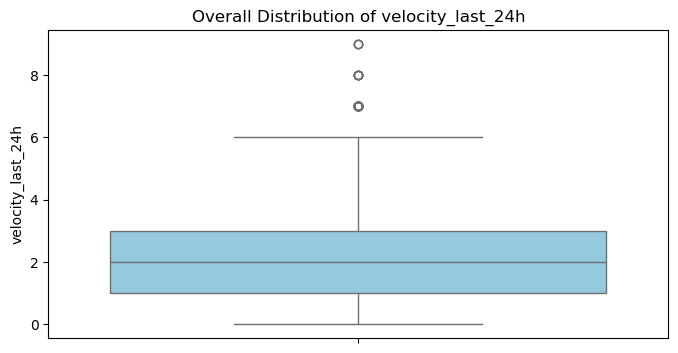

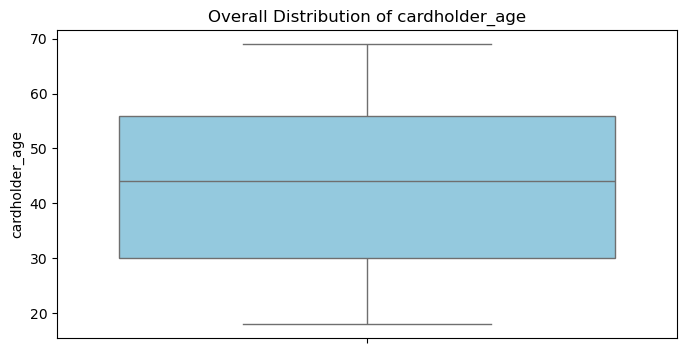


Violin Plots of Numerical Features:


C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\674139589.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,


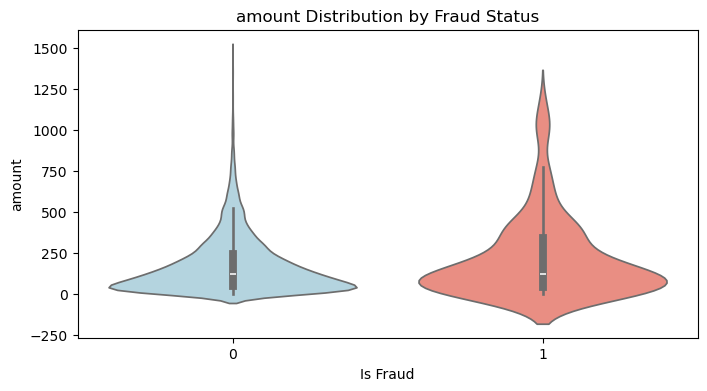

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\674139589.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,


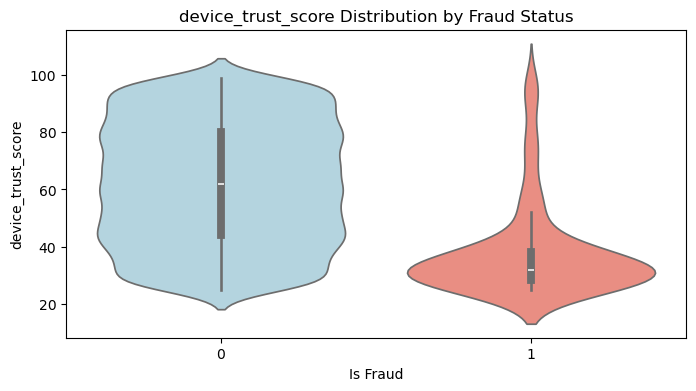

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\674139589.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,


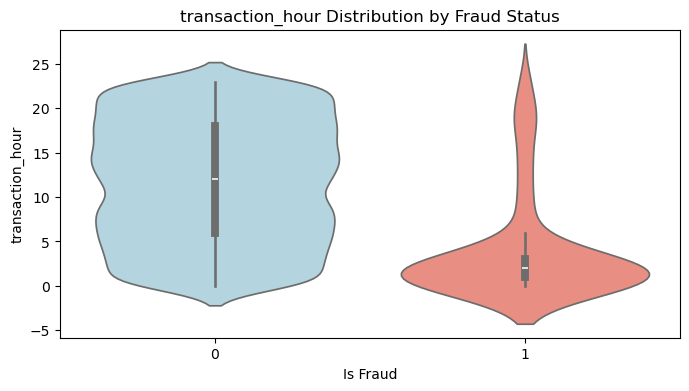

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\674139589.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,


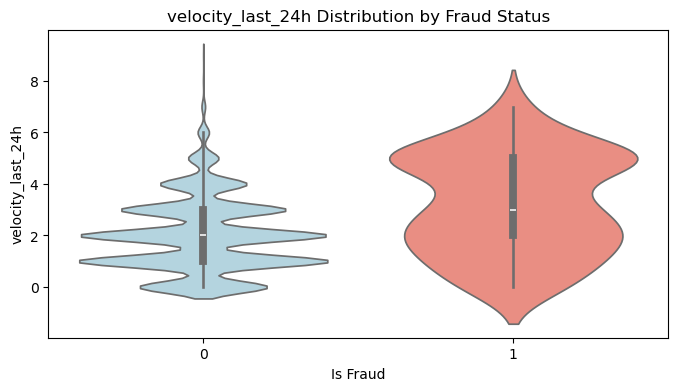

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\674139589.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_fraud', y=col, data=credit_data_df,


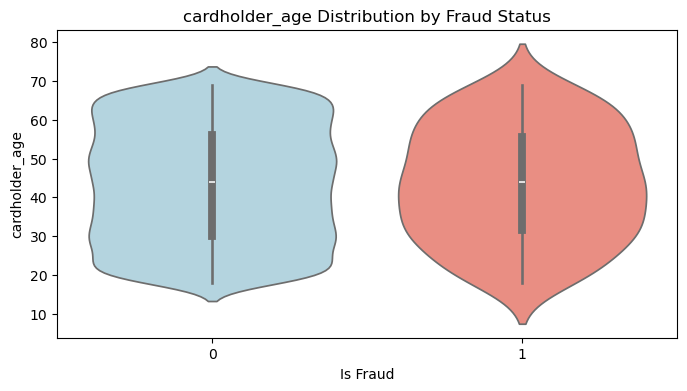

In [70]:
numerical_cols = ['amount', 'device_trust_score', 'transaction_hour' , 
                    'velocity_last_24h', 'cardholder_age']

print("\nHistograms of Numerical Features:")
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(
        credit_data_df[col], 
        bins=30, 
        color='skyblue'
        )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

print("\nKDE Plots of Numerical Features:")
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    
    sns.kdeplot(
        data=credit_data_df, 
        x=col, 
        hue='is_fraud', 
        fill=True, 
        common_norm=False, 
        palette=['lightblue', 'salmon'],
        clip=(0, None) 
        )
    
    plt.title(f'{col} Distribution by Fraud Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

print("\nBox Plots of Numerical Features:")
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        y=credit_data_df[col], 
        color='skyblue'
        )
    plt.title(f'Overall Distribution of {col}')
    plt.ylabel(col)
    plt.show()

print("\nViolin Plots of Numerical Features:")
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.violinplot(x='is_fraud', y=col, data=credit_data_df, 
                    palette=['lightblue', 'salmon'])
    plt.title(f'{col} Distribution by Fraud Status')
    plt.xlabel('Is Fraud')
    plt.ylabel(col)
    plt.show()




### Univariate Analysis – Categorical Features


Bar Charts of Categorical Features:


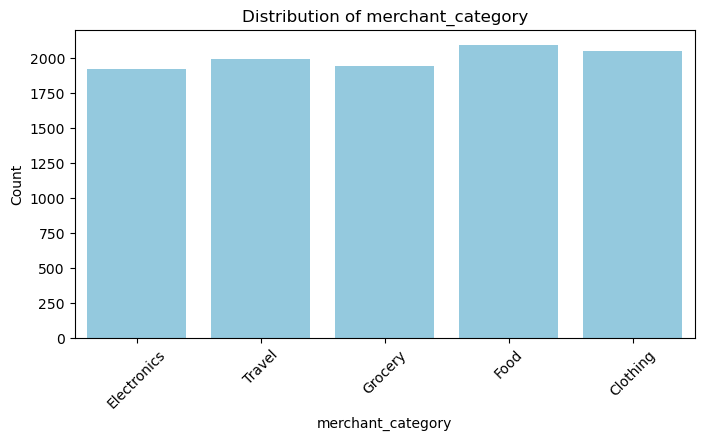

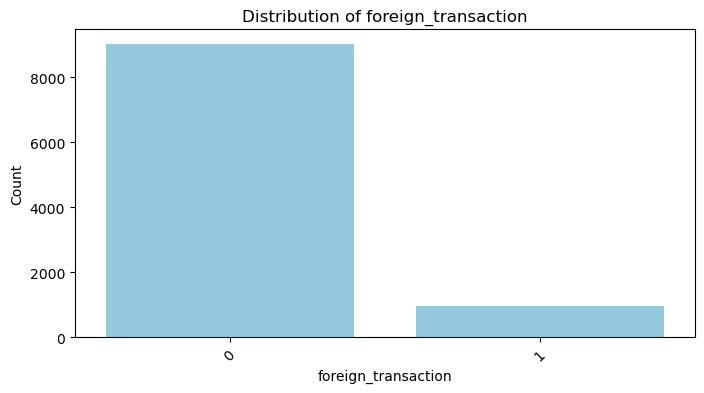

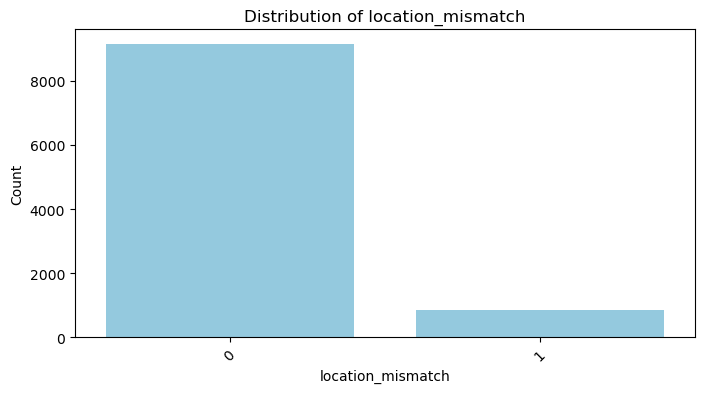


Pie Charts of Categorical Features:


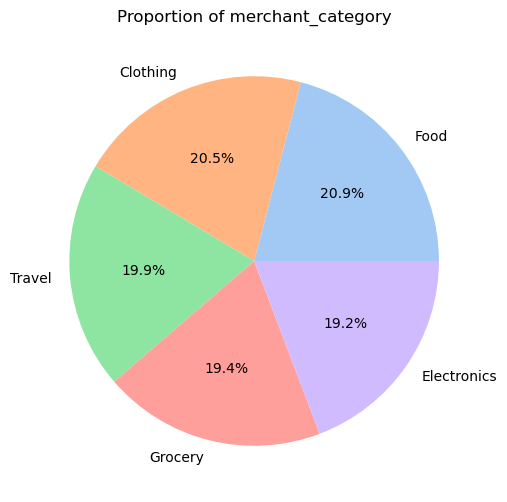

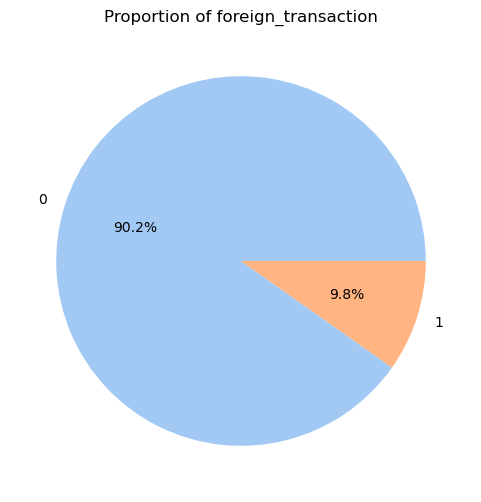

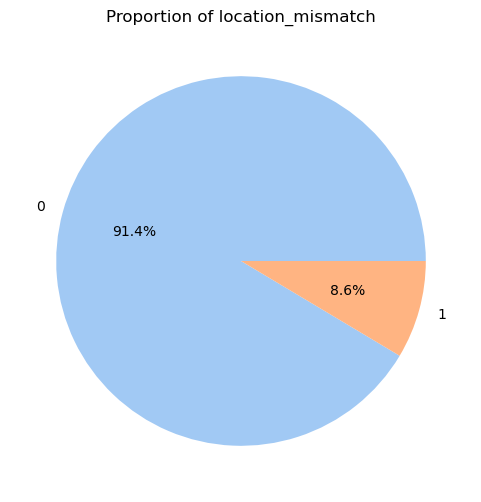

In [71]:
categorical_cols = ['merchant_category', 'foreign_transaction' , 'location_mismatch']

print("\nBar Charts of Categorical Features:")
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        x=col, 
        data=credit_data_df, 
        color='skyblue'
        )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

print("\nPie Charts of Categorical Features:")
for col in categorical_cols:
    plt.figure(figsize=(6, 6))
    counts = credit_data_df[col].value_counts()
    plt.pie(
        counts.values, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        colors=sns.color_palette('pastel')
        )
    plt.title(f'Proportion of {col}')
    plt.show()


### Bivariate Analysis – Numerical vs Target


Box plot by using the target variable ('is_fraud'):


C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\1776590397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


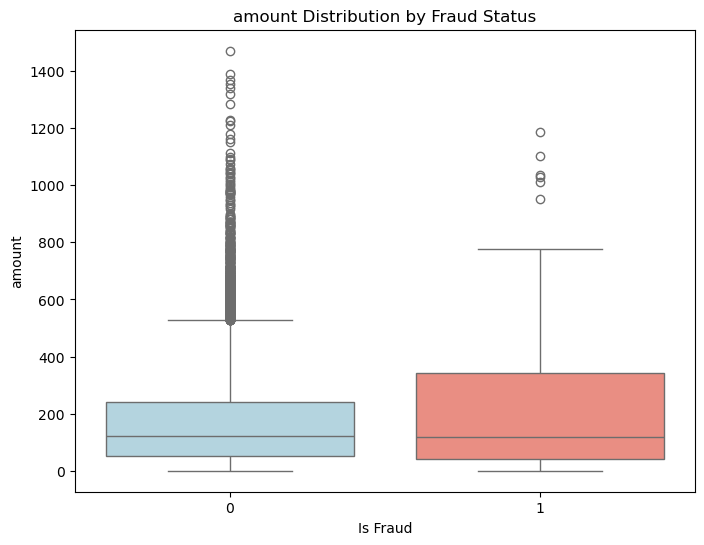

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\1776590397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


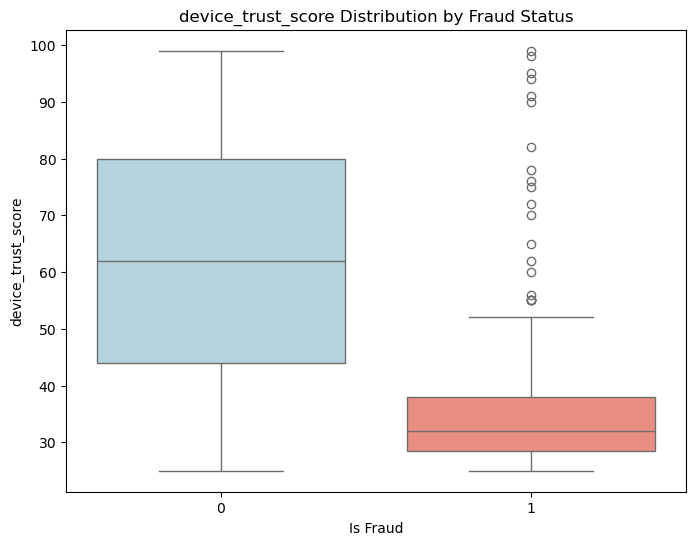

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\1776590397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


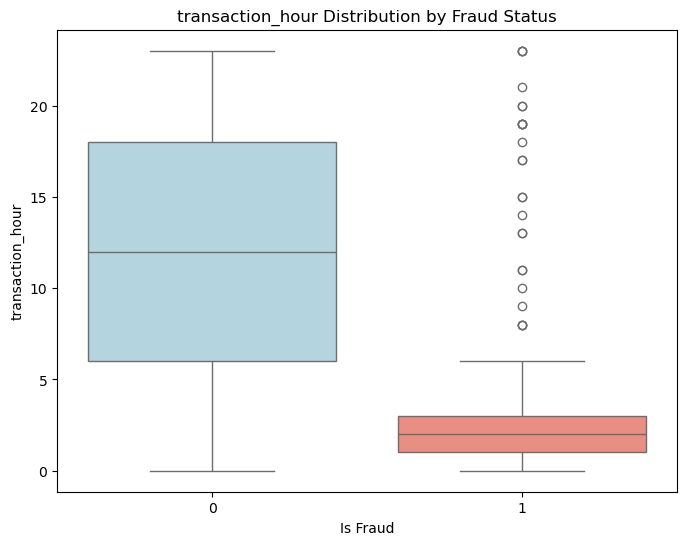

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\1776590397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


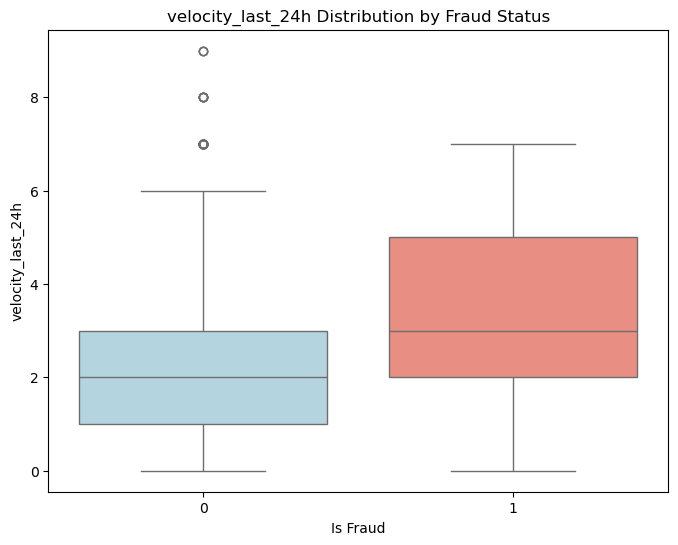

C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\1776590397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


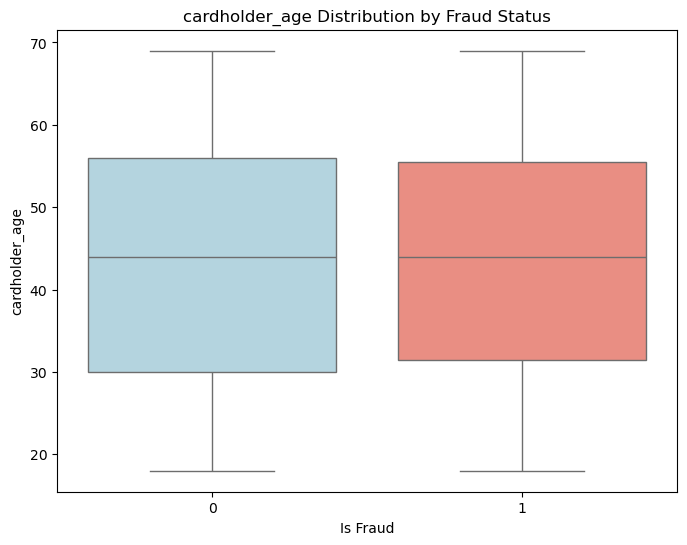


Strip and Swarm Plots by using the target variable ('is_fraud'):
Note: These plots can be slow to render on large datasets, so we will sample 1000 rows for better performance.
Strip Plot (light blue) and Swarm Plot (salmon) for each numerical feature:


c:\Users\ben10\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ben10\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 30.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


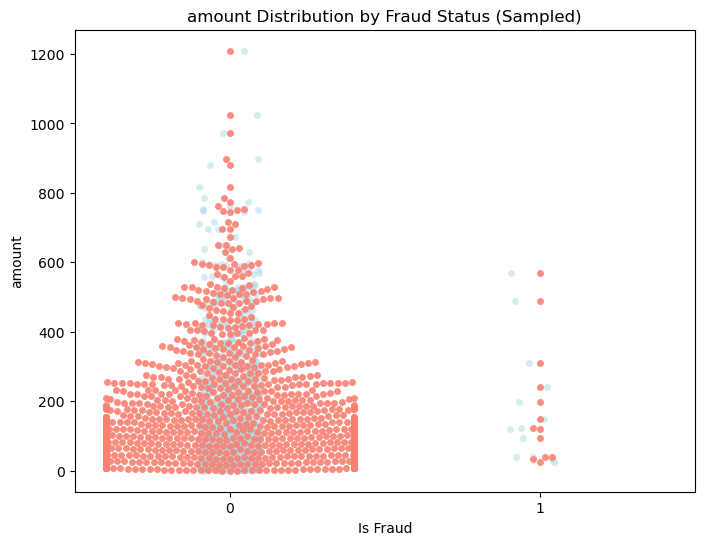

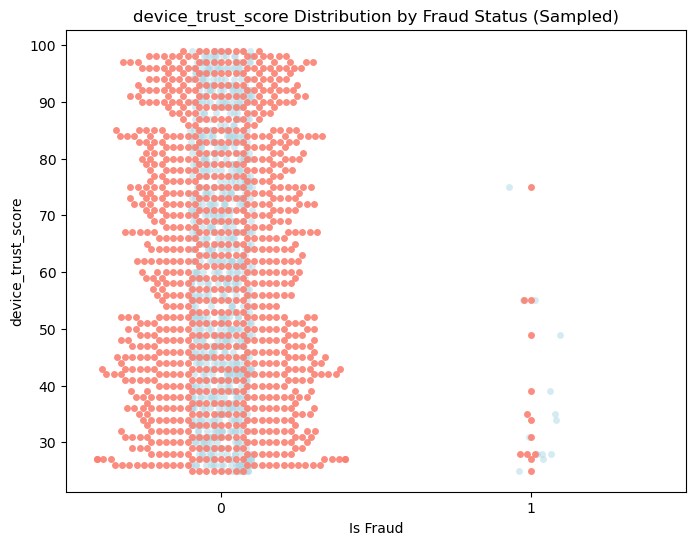

c:\Users\ben10\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 17.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


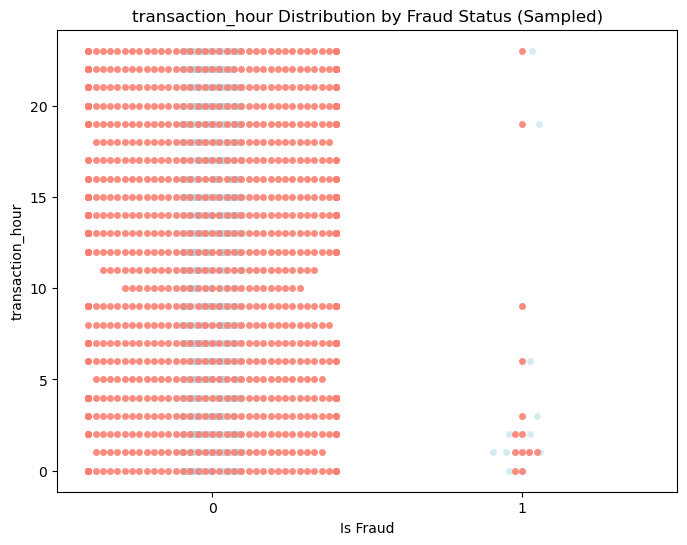

c:\Users\ben10\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 69.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\ben10\miniconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 77.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


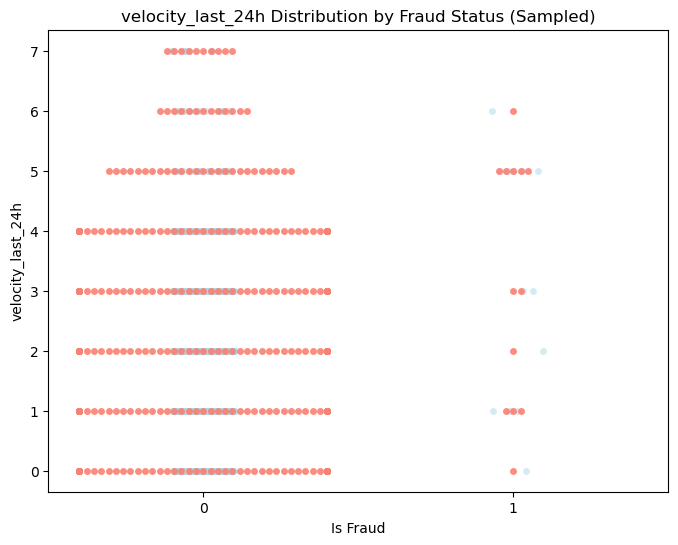

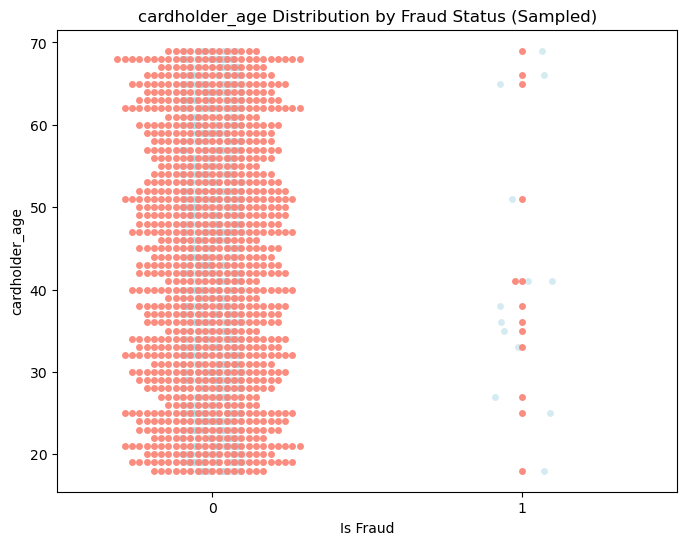


Rows of Histograms of Numerical Features by Fraud Status:


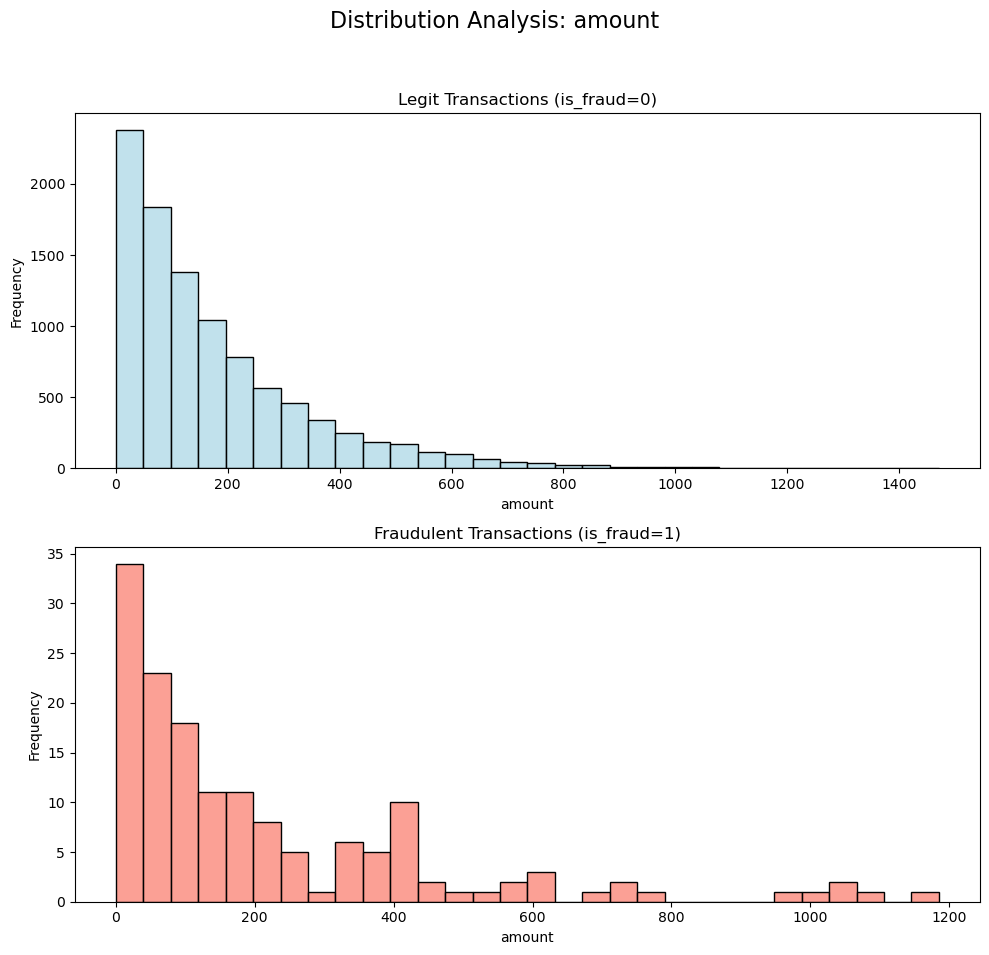

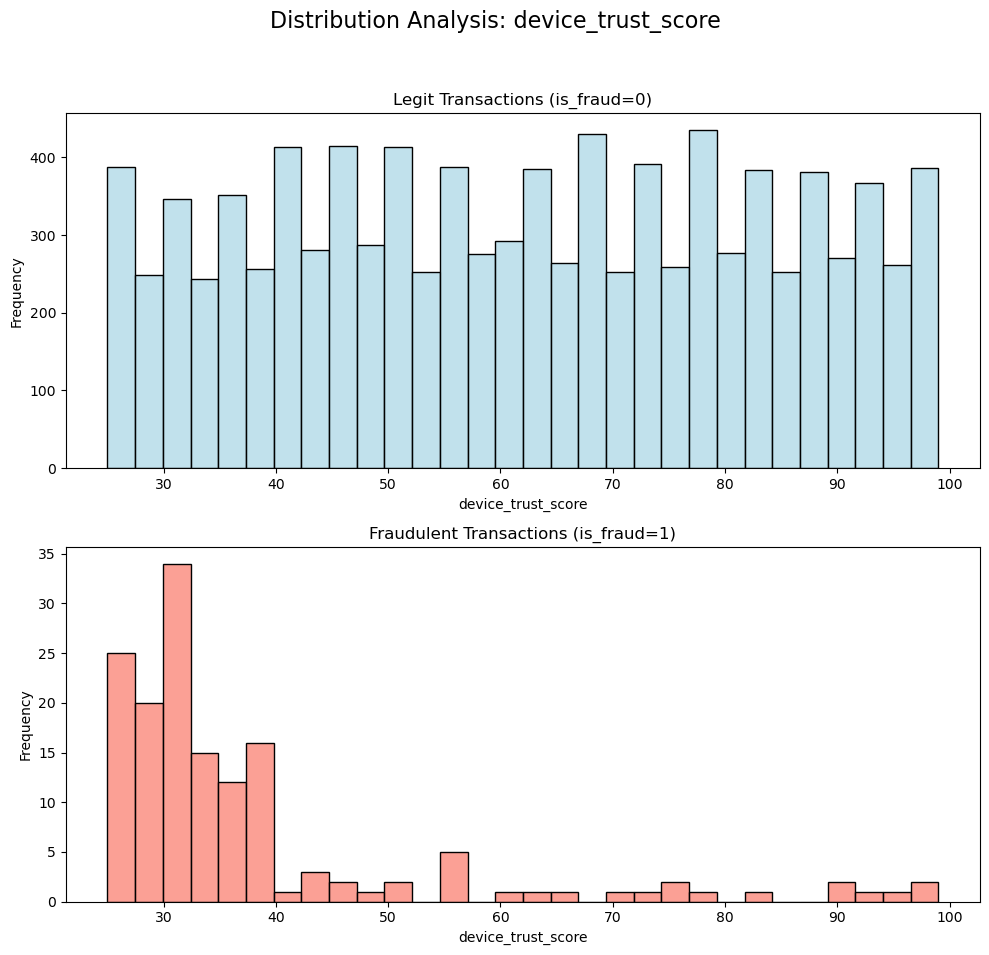

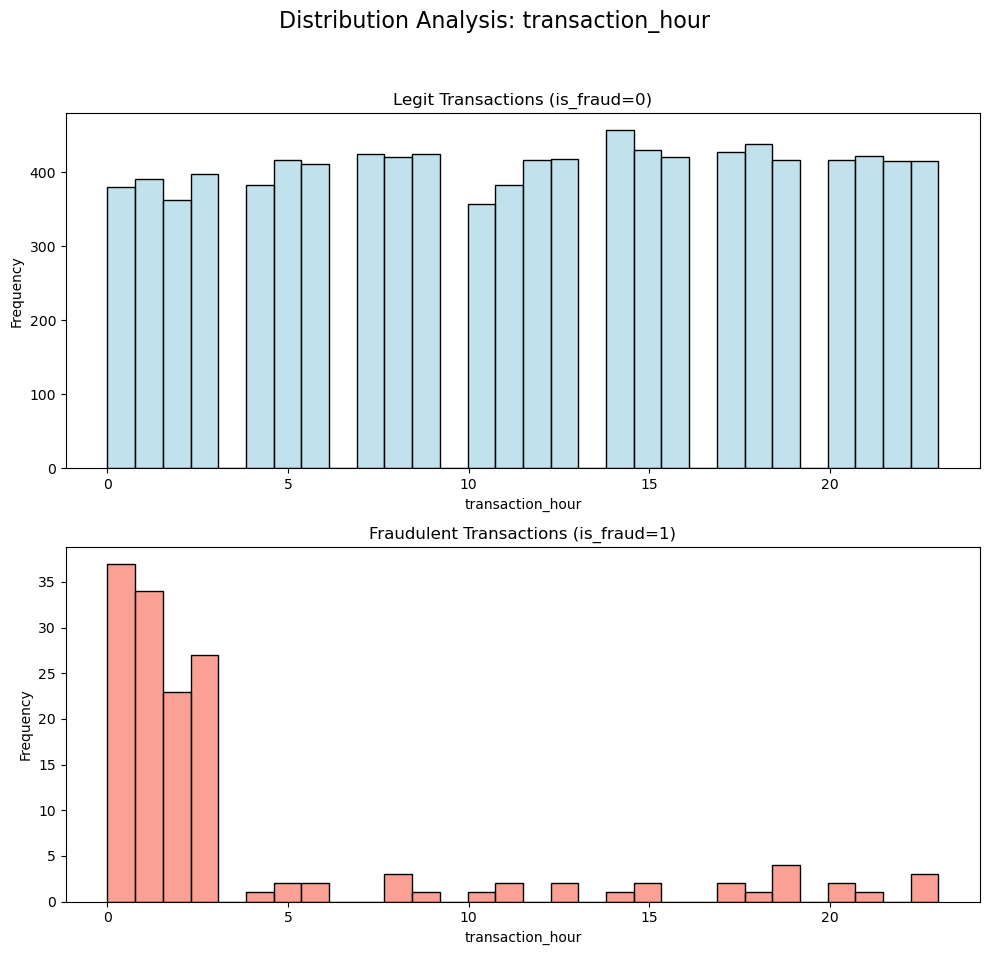

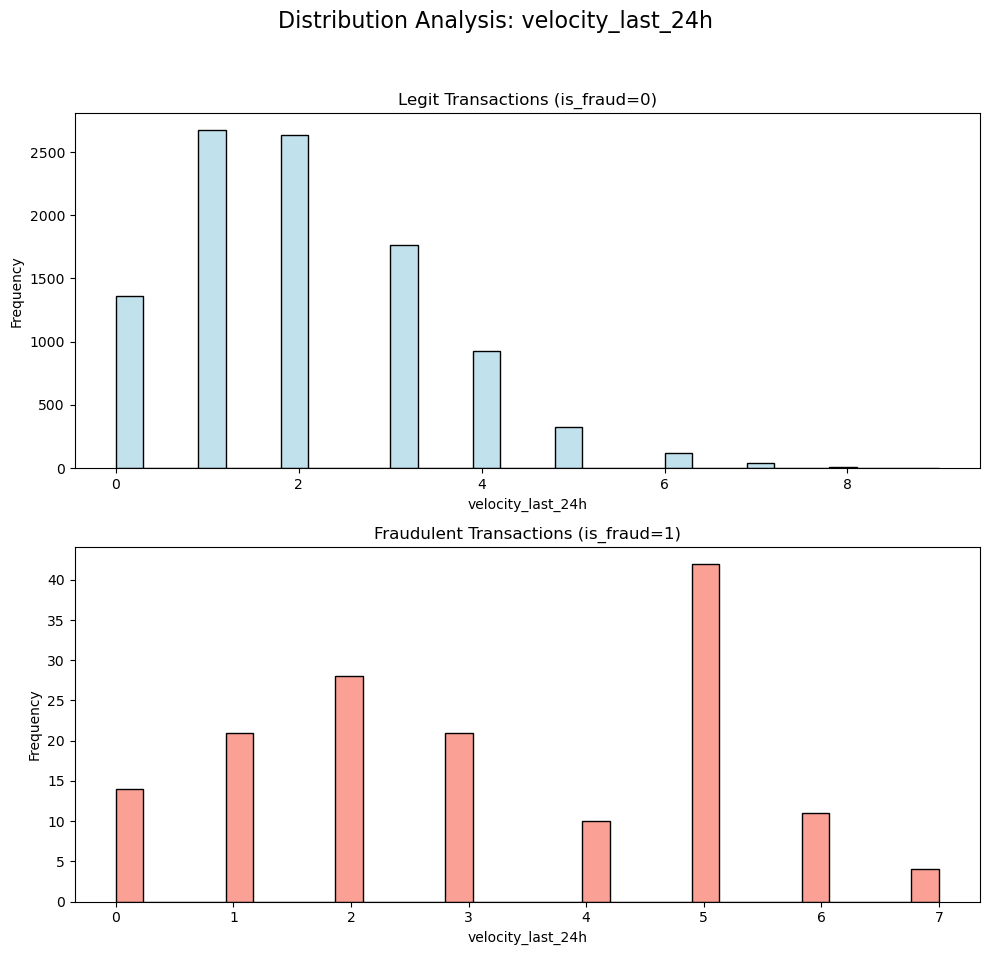

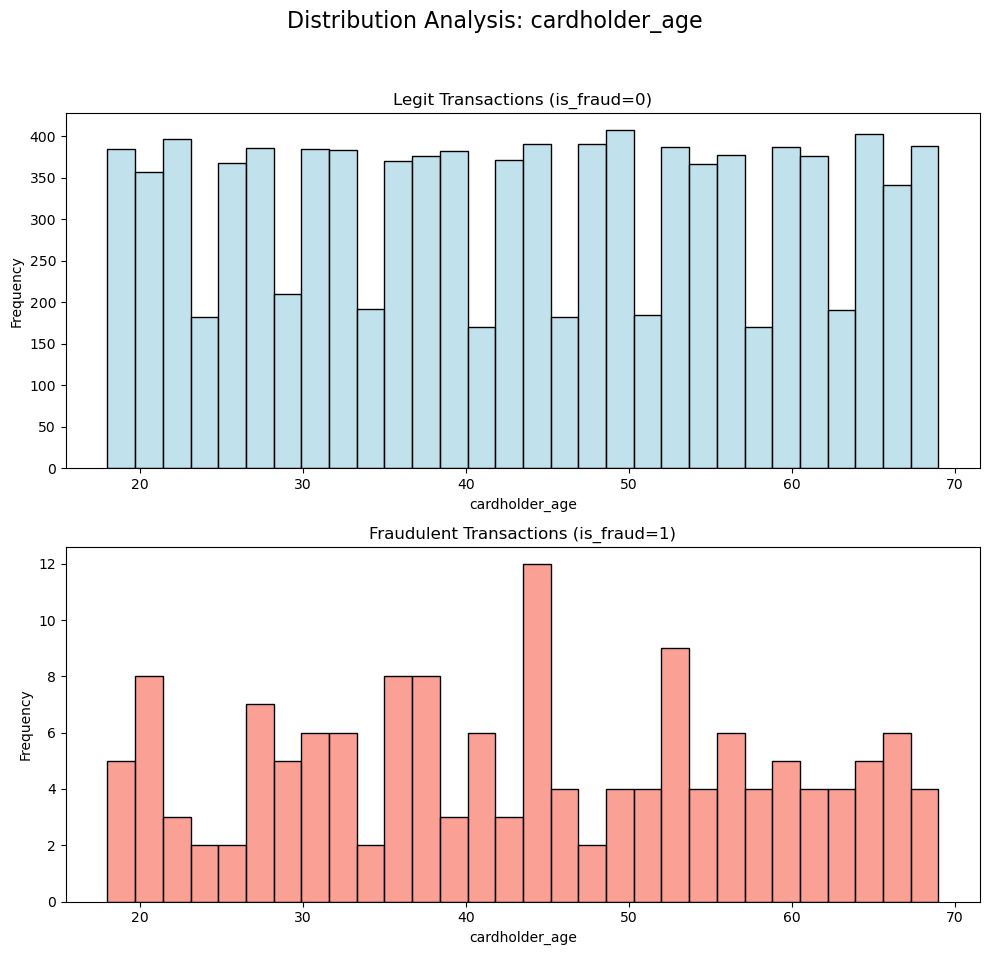

In [72]:
print("\nBox plot by using the target variable ('is_fraud'):")
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        x='is_fraud', 
        y=col, 
        data=credit_data_df, 
        palette=['lightblue', 'salmon']
        )
    plt.title(f'{col} Distribution by Fraud Status')
    plt.xlabel('Is Fraud')
    plt.ylabel(col)
    plt.show()

print("\nStrip and Swarm Plots by using the target variable ('is_fraud'):")
print("Note: These plots can be slow to render on large datasets, so we will sample 1000 rows for better performance.")
print("Strip Plot (light blue) and Swarm Plot (salmon) for each numerical feature:")
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.stripplot(
        x='is_fraud', 
        y=col, 
        data=credit_data_df.sample(1000, random_state=42), 
        color='lightblue', 
        alpha=0.5
        )
    sns.swarmplot(
        x='is_fraud', 
        y=col, 
        data=credit_data_df.sample(1000, random_state=42), 
        color='salmon', 
        alpha=0.9
        )
    plt.title(f'{col} Distribution by Fraud Status (Sampled)')
    plt.xlabel('Is Fraud')
    plt.ylabel(col)
    plt.show()

# Rows of histogram (one for each numerical feature with is_fraud = 1 and one for is_fraud = 0)
print("\nRows of Histograms of Numerical Features by Fraud Status:")
for col in numerical_cols:
    fig, axes = plt.subplots(
                    2, 
                    1, 
                    figsize=(10, 10), 
                    sharex=False
                    )
    fig.suptitle(f'Distribution Analysis: {col}', fontsize=16)
    sns.histplot(
        data=credit_data_df[credit_data_df['is_fraud'] == 0], 
        x=col, 
        bins=30, 
        color='lightblue', 
        edgecolor='black',
        ax=axes[0]
        )
    axes[0].set_title('Legit Transactions (is_fraud=0)')
    axes[0].set_ylabel('Frequency')
    sns.histplot(
        data=credit_data_df[credit_data_df['is_fraud'] == 1], 
        x=col, 
        bins=30, 
        color='salmon', 
        edgecolor='black',
        ax=axes[1]
        )
    axes[1].set_title('Fraudulent Transactions (is_fraud=1)')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Bivariate Analysis – Categorical vs Target


Two-Way Contingency Table for Categorical Features vs Fraud Status:

Contingency Table for merchant_category vs is_fraud:


is_fraud,0,1,Total
merchant_category,,,
Clothing,2026,24,2050
Electronics,1899,24,1923
Food,2058,35,2093
Grocery,1905,39,1944
Travel,1961,29,1990
Total,9849,151,10000



Contingency Table for foreign_transaction vs is_fraud:


is_fraud,0,1,Total
foreign_transaction,,,
0,8953,69,9022
1,896,82,978
Total,9849,151,10000



Contingency Table for location_mismatch vs is_fraud:


is_fraud,0,1,Total
location_mismatch,,,
0,9064,79,9143
1,785,72,857
Total,9849,151,10000



Clustered Bar Charts for Categorical Features by Fraud Status:


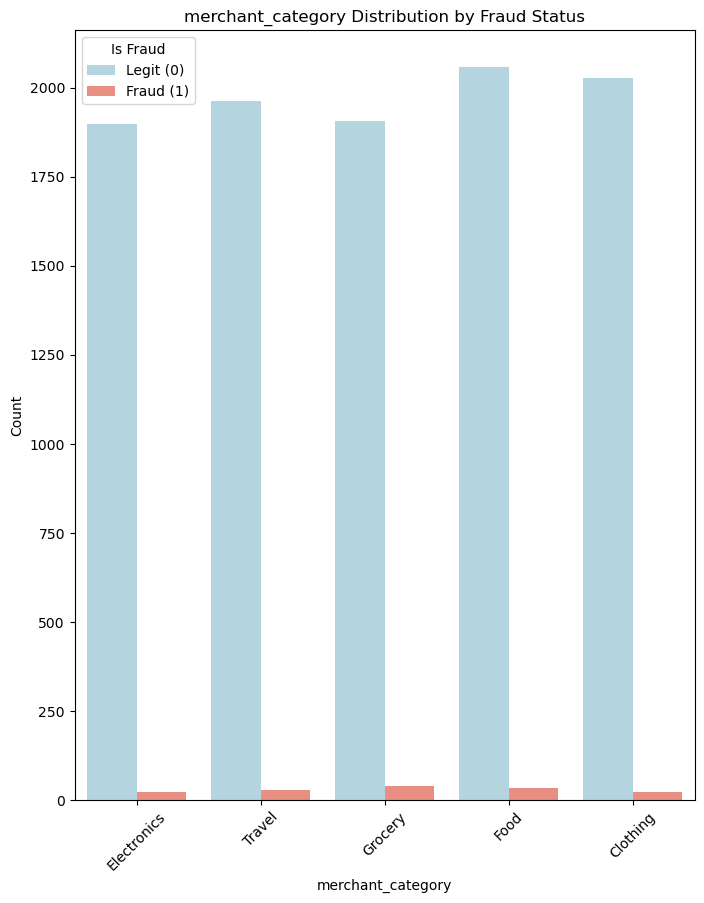

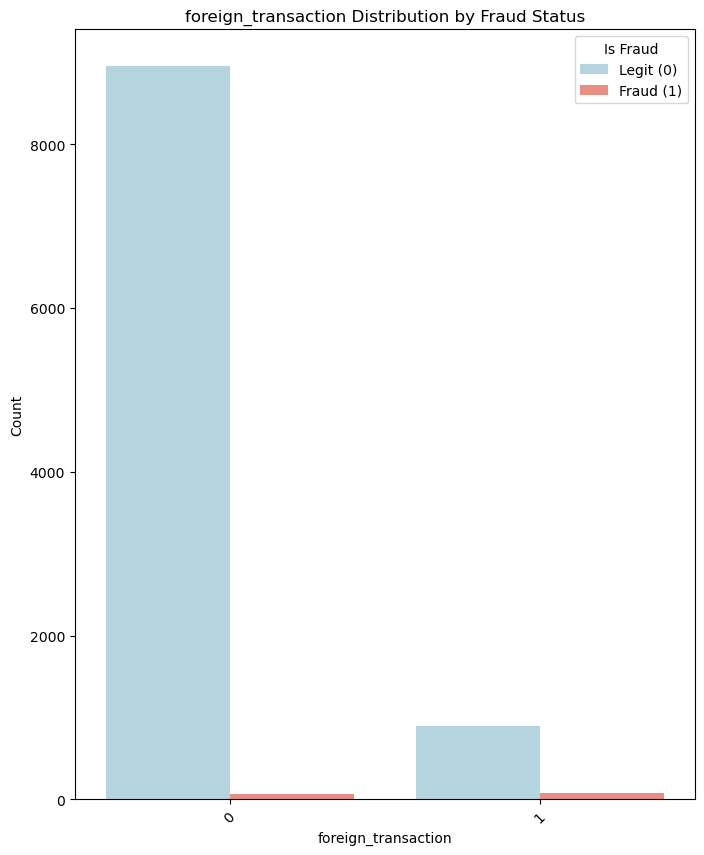

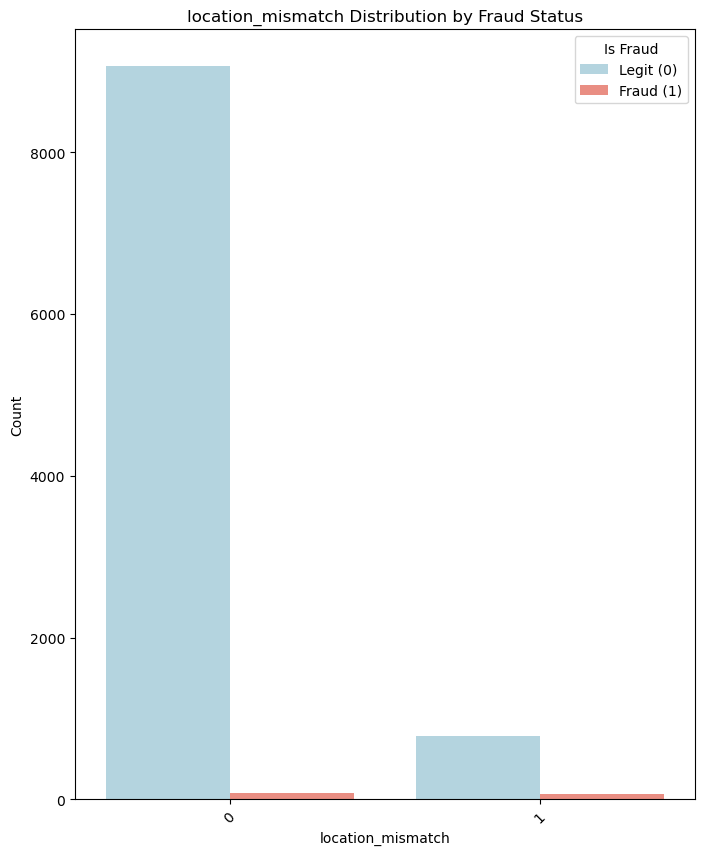


Stacked Bar Charts for Categorical Features by Fraud Status:


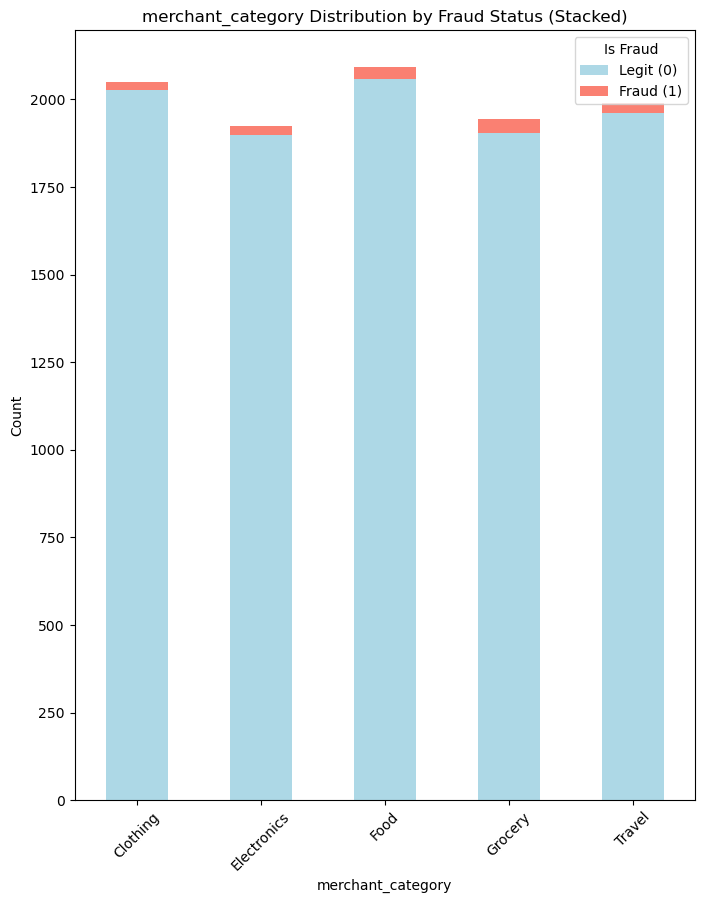

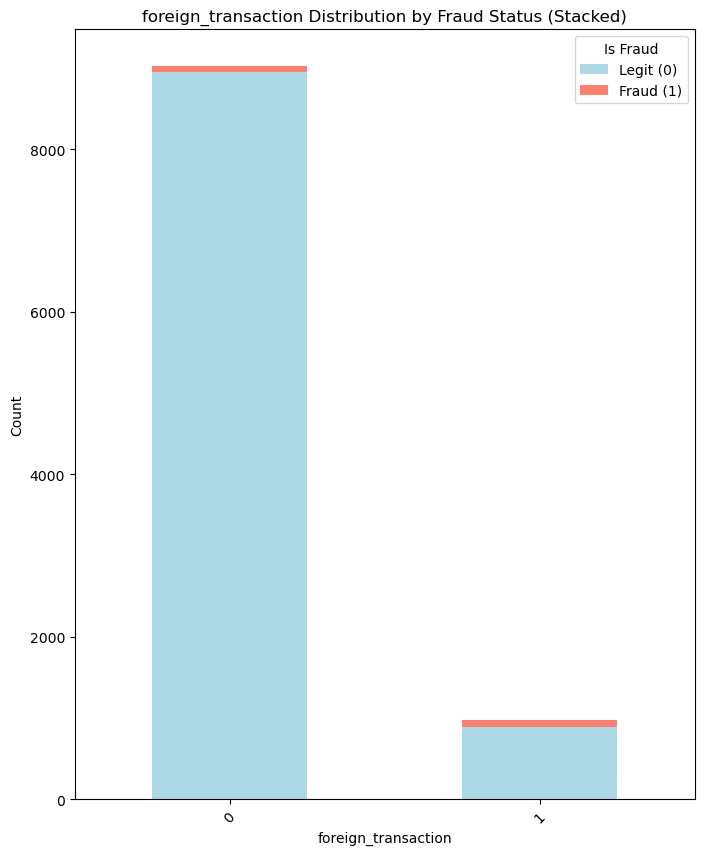

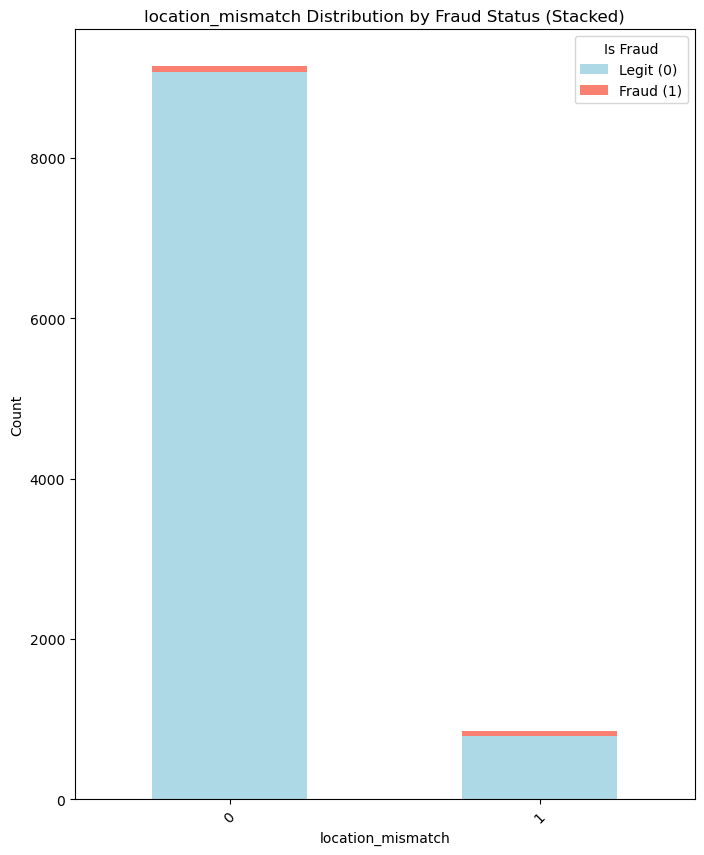


Multiple Pie Charts for Categorical Features by Fraud Status:


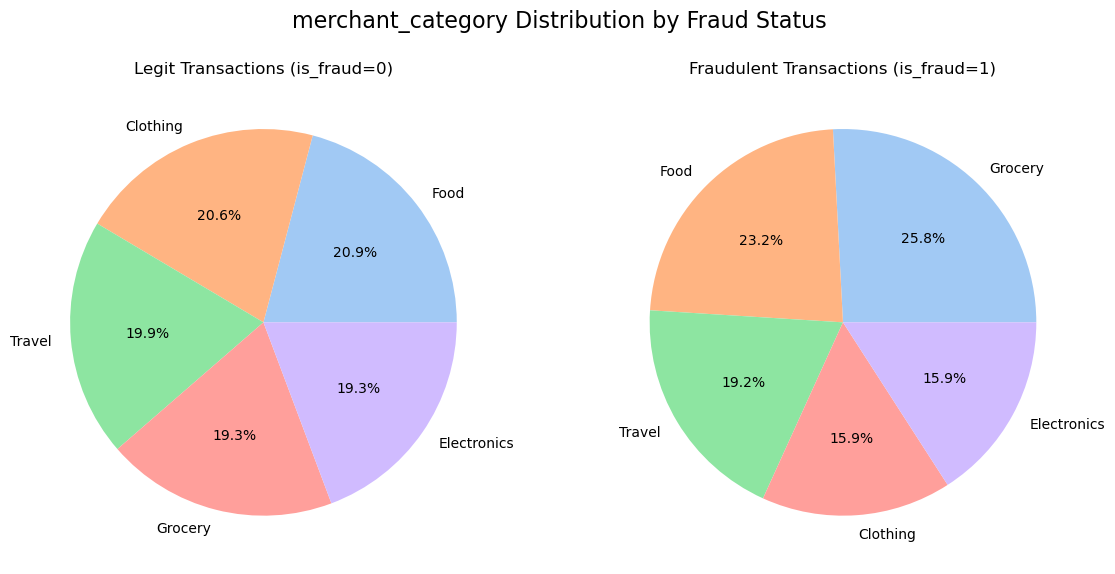

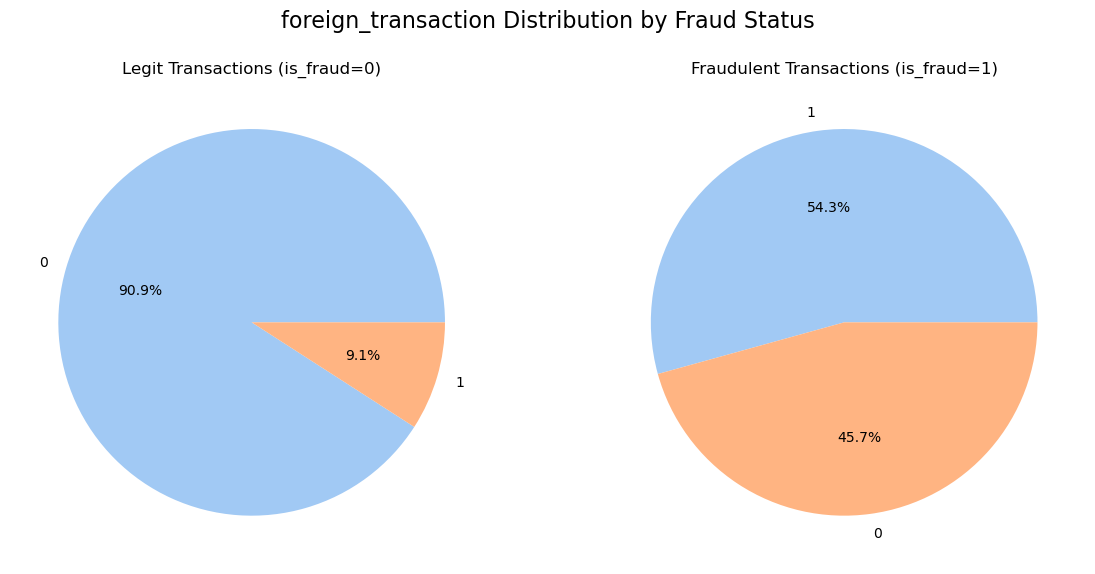

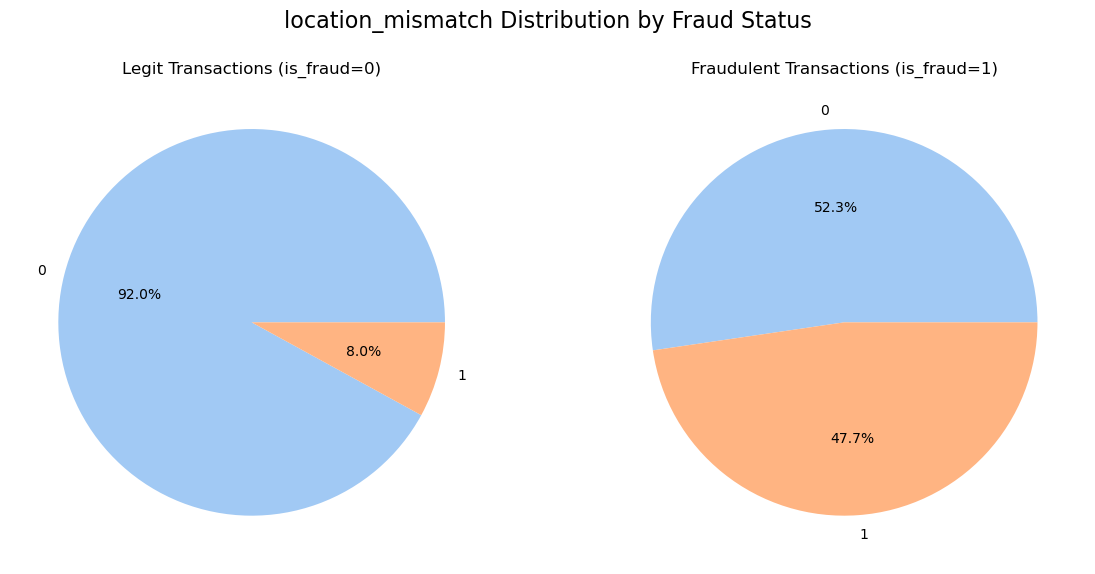


Crosstab for Categorical Features vs Fraud Status:

Crosstab for merchant_category vs is_fraud (Fraud Rate):


is_fraud,0,1
merchant_category,,
Clothing,2026,24
Electronics,1899,24
Food,2058,35
Grocery,1905,39
Travel,1961,29



Crosstab for foreign_transaction vs is_fraud (Fraud Rate):


is_fraud,0,1
foreign_transaction,,
0,8953,69
1,896,82



Crosstab for location_mismatch vs is_fraud (Fraud Rate):


is_fraud,0,1
location_mismatch,,
0,9064,79
1,785,72



Heatmaps of Categorical Features vs Fraud Status:


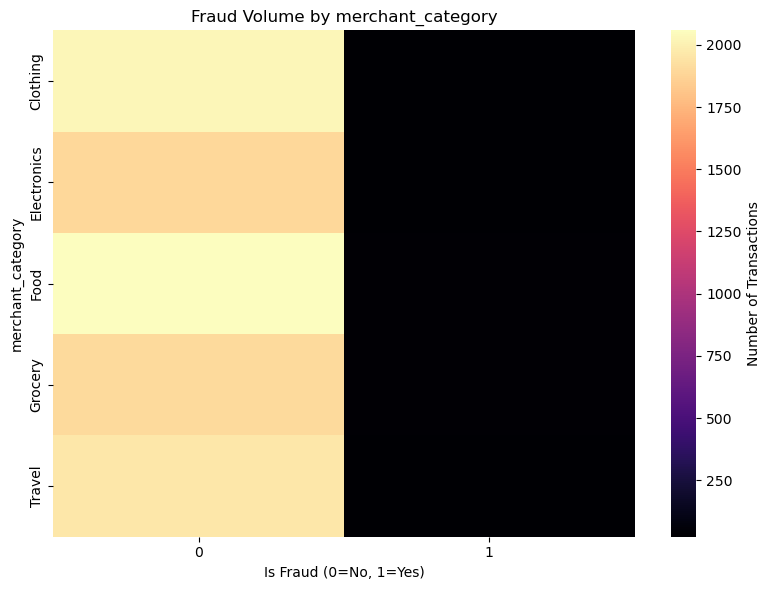

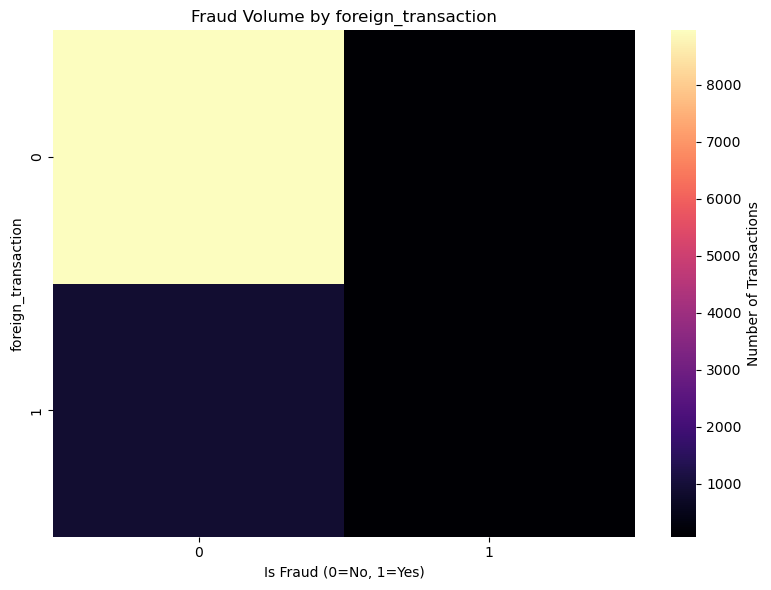

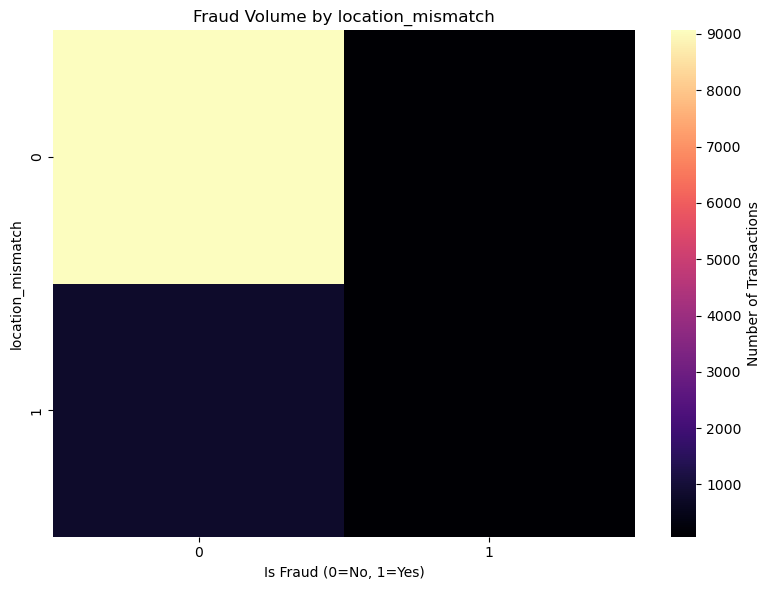

In [73]:
print("\nTwo-Way Contingency Table for Categorical Features vs Fraud Status:")
for col in categorical_cols:
    contingency_table = pd.crosstab(
                            credit_data_df[col], 
                            credit_data_df['is_fraud'],
                            margins=True,
                            margins_name='Total'
                            )
    print(f"\nContingency Table for {col} vs is_fraud:")
    display(contingency_table)

print("\nClustered Bar Charts for Categorical Features by Fraud Status:")
for col in categorical_cols:
    plt.figure(figsize=(8, 10))
    sns.countplot(
        x=col, 
        hue='is_fraud', 
        data=credit_data_df, 
        palette=['lightblue', 'salmon']
        )
    plt.title(f'{col} Distribution by Fraud Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
    plt.show()

print("\nStacked Bar Charts for Categorical Features by Fraud Status:")
for col in categorical_cols:
    counts = credit_data_df.groupby([col, 'is_fraud']).size().unstack(fill_value=0)
    counts.plot(
        kind='bar', 
        stacked=True, 
        color=['lightblue', 'salmon'], 
        figsize=(8, 10)
        )
    plt.title(f'{col} Distribution by Fraud Status (Stacked)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
    plt.show()

print("\nMultiple Pie Charts for Categorical Features by Fraud Status:")
for col in categorical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f'{col} Distribution by Fraud Status', fontsize=16)
    
    fraud_counts = credit_data_df[credit_data_df['is_fraud'] == 0][col].value_counts()
    axes[0].pie(
        fraud_counts.values, 
        labels=fraud_counts.index, 
        autopct='%1.1f%%', 
        colors=sns.color_palette('pastel')
        )
    axes[0].set_title('Legit Transactions (is_fraud=0)')
    
    fraud_counts = credit_data_df[credit_data_df['is_fraud'] == 1][col].value_counts()
    axes[1].pie(
        fraud_counts.values, 
        labels=fraud_counts.index, 
        autopct='%1.1f%%', 
        colors=sns.color_palette('pastel')
        )
    axes[1].set_title('Fraudulent Transactions (is_fraud=1)')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("\nCrosstab for Categorical Features vs Fraud Status:")
for col in categorical_cols:
    crosstab = pd.crosstab(
                    credit_data_df[col], 
                    credit_data_df['is_fraud']
                    )
    print(f"\nCrosstab for {col} vs is_fraud (Fraud Rate):")
    display(crosstab)

print("\nHeatmaps of Categorical Features vs Fraud Status:")
for col in categorical_cols:
    crosstab = pd.crosstab(
                    credit_data_df[col], 
                    credit_data_df['is_fraud']
                    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        crosstab, 
        annot=False, 
        fmt='d', 
        cmap='magma',
        cbar_kws={'label': 'Number of Transactions'}
        )
    plt.title(f'Fraud Volume by {col}')
    plt.xlabel('Is Fraud (0=No, 1=Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### Multivariate Analysis


Correlation Matrix of Numerical Features:


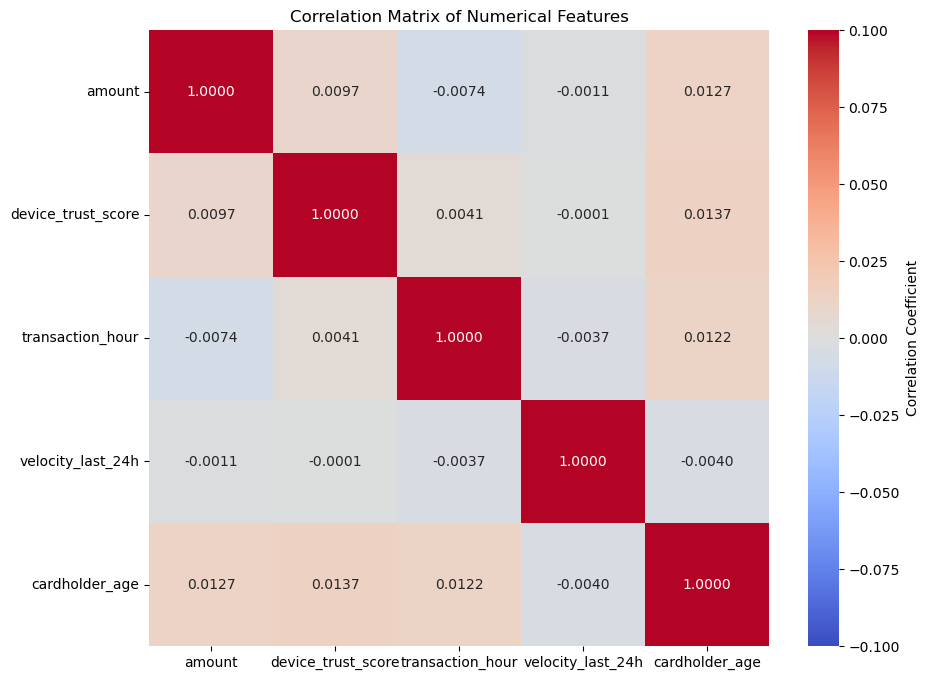


Pair Plots (Scatterplot Matrices) of Numerical Features Colored by Fraud Status:


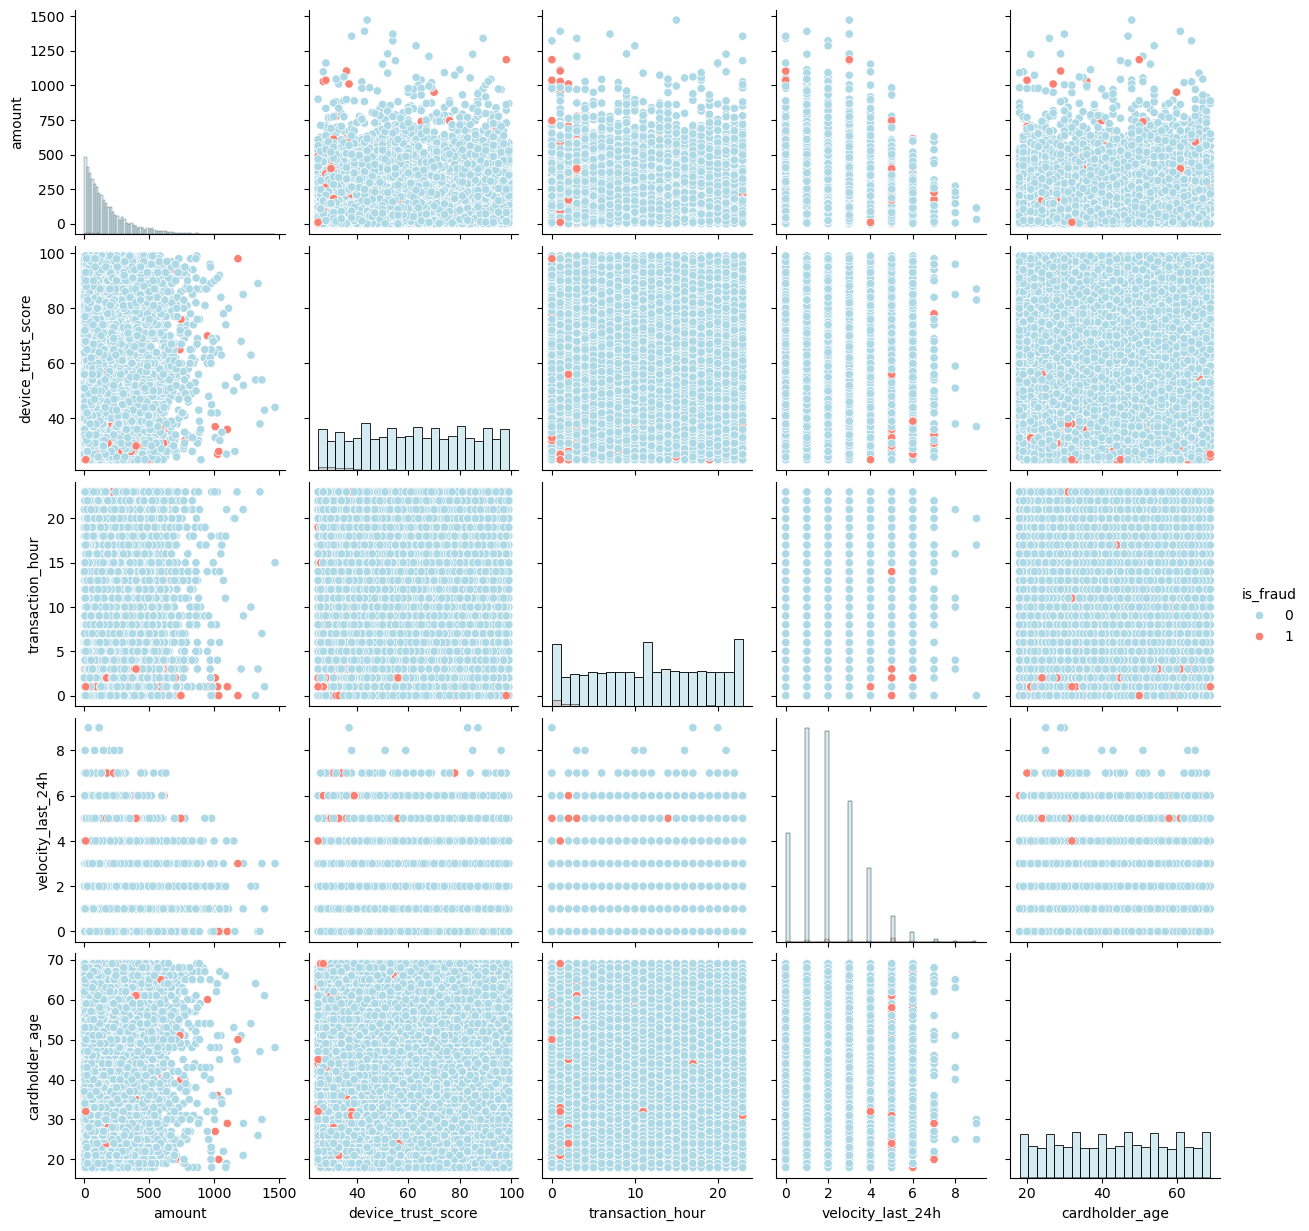


Parallel Coordinates Plot of Numerical Features Colored by Fraud Status:


C:\Users\ben10\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


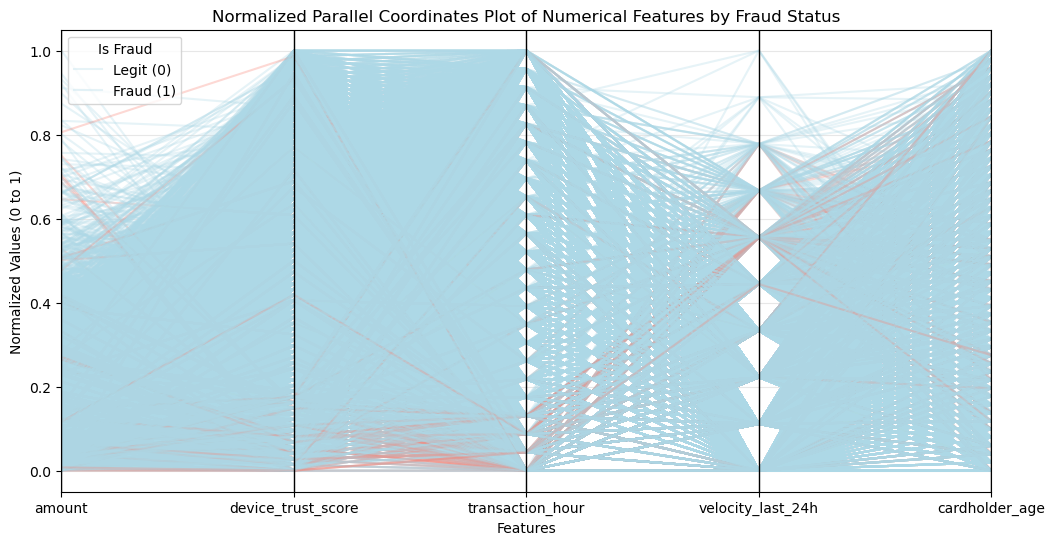


3D Scatter Plot of Amount, Device Trust Score and Velocity Last 24h Colored by Fraud Status:


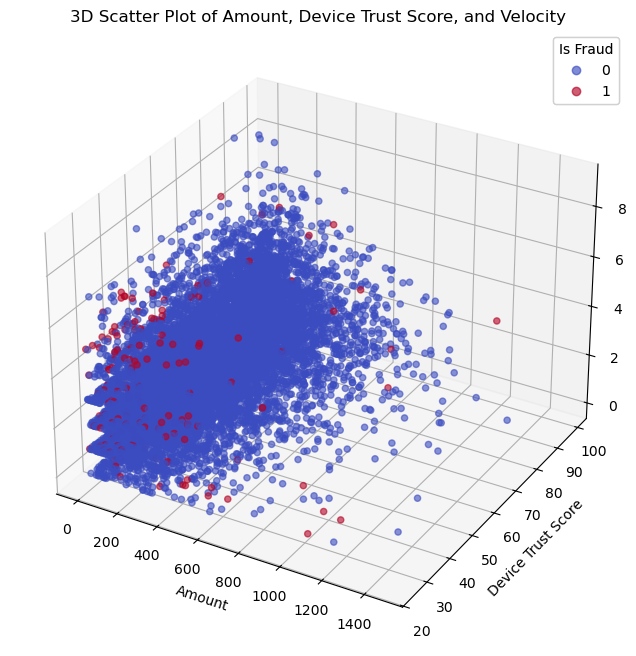


3D Scatter Plot of Amount, Cardholder Age and Transaction Hour Colored by Fraud Status:


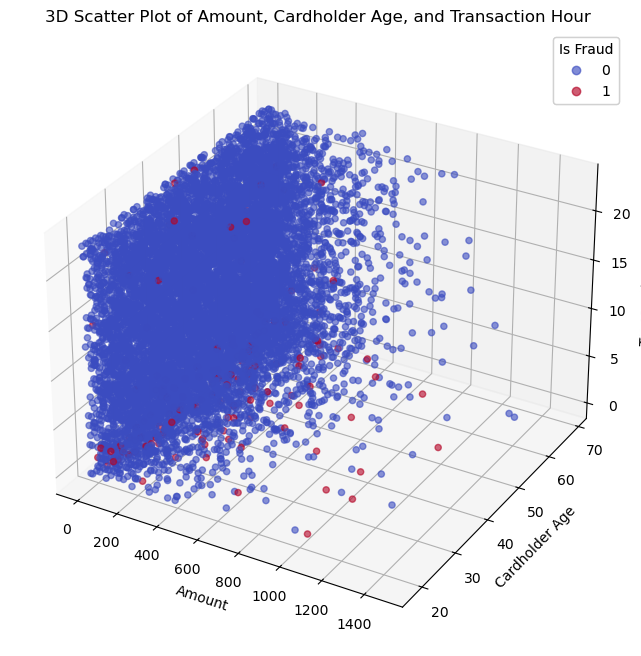


Bubble Charts of Amount vs Device Trust Score with Bubble Size Representing Velocity Last 24h:


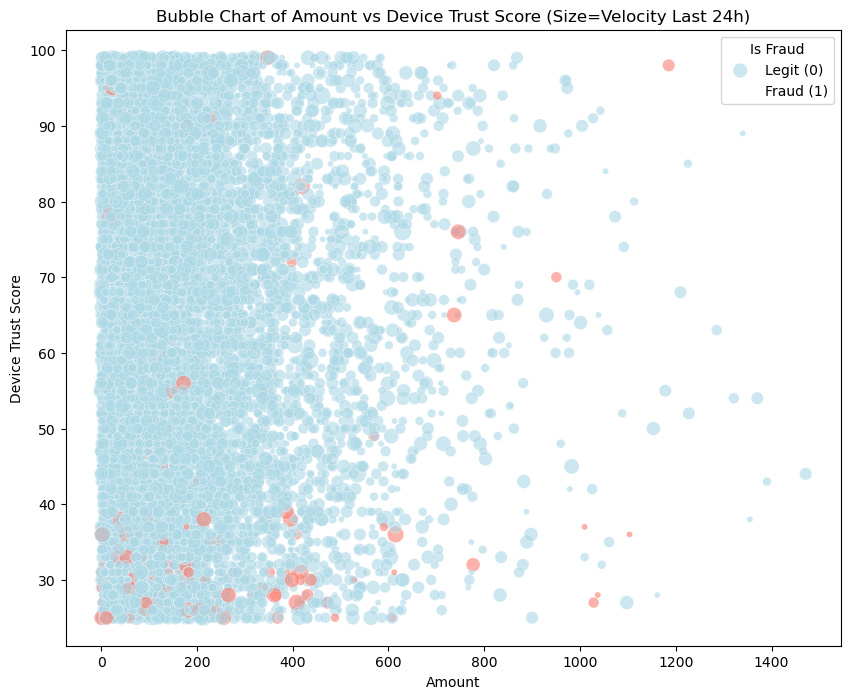


Bubble Charts of Amount vs Cardholder Age with Bubble Size Representing Transaction Hour:


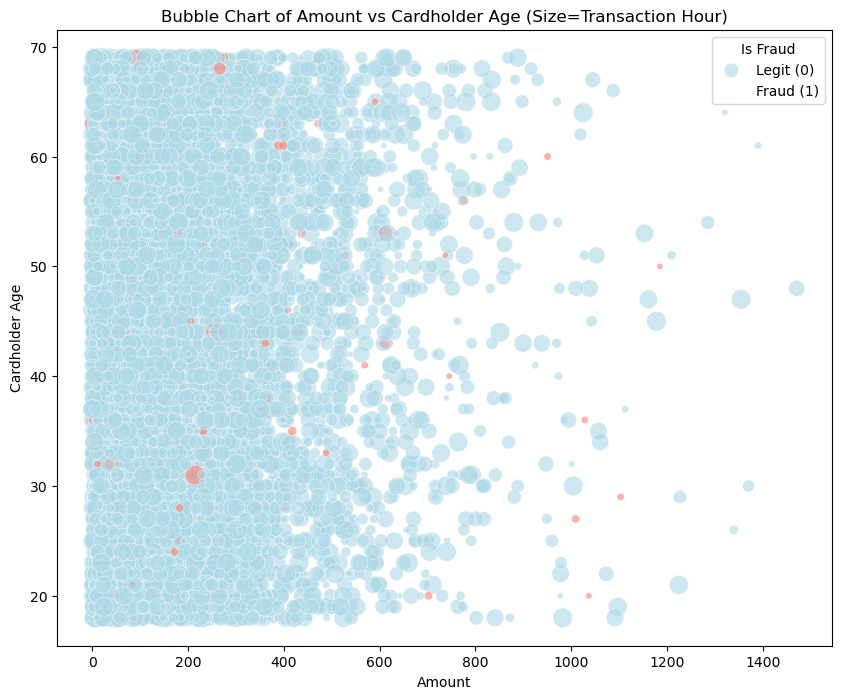

In [74]:
print("\nCorrelation Matrix of Numerical Features:")
corr_matrix = credit_data_df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.4f', 
    cmap='coolwarm', 
    vmin=-0.1,
    vmax=0.1,
    center=0,
    cbar_kws={'label': 'Correlation Coefficient'}
    )
plt.title('Correlation Matrix of Numerical Features')
plt.show()


print("\nPair Plots (Scatterplot Matrices) of Numerical Features Colored by Fraud Status:")
sns.pairplot(
    credit_data_df[numerical_cols + ['is_fraud']], 
    hue='is_fraud', 
    palette=['lightblue', 'salmon'], 
    diag_kind='hist'
    )
plt.show()


print("\nParallel Coordinates Plot of Numerical Features Colored by Fraud Status:")
df_scaled = credit_data_df.copy()
for col in numerical_cols:
    df_scaled[col] = (df_scaled[col] - df_scaled[col].min()) / (df_scaled[col].max() - df_scaled[col].min())

plt.figure(figsize=(12, 6))
parallel_coordinates(
    df_scaled[numerical_cols + ['is_fraud']], 
    class_column='is_fraud', 
    color=['lightblue', 'salmon'], 
    alpha=0.3
    )
plt.title('Normalized Parallel Coordinates Plot of Numerical Features by Fraud Status')
plt.xlabel('Features')
plt.ylabel('Normalized Values (0 to 1)')
plt.legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
plt.grid(True, alpha=0.3)
plt.show()


print("\n3D Scatter Plot of Amount, Device Trust Score and Velocity Last 24h Colored by Fraud Status:")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    credit_data_df['amount'], 
    credit_data_df['device_trust_score'], 
    credit_data_df['velocity_last_24h'], 
    c=credit_data_df['is_fraud'], 
    cmap='coolwarm', 
    alpha=0.6
    )
ax.set_title('3D Scatter Plot of Amount, Device Trust Score, and Velocity')
ax.set_xlabel('Amount')
ax.set_ylabel('Device Trust Score')
ax.set_zlabel('Velocity Last 24h')
legend1 = ax.legend(*scatter.legend_elements(), title="Is Fraud")
ax.add_artist(legend1)
plt.show()

print("\n3D Scatter Plot of Amount, Cardholder Age and Transaction Hour Colored by Fraud Status:")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    credit_data_df['amount'], 
    credit_data_df['cardholder_age'], 
    credit_data_df['transaction_hour'], 
    c=credit_data_df['is_fraud'], 
    cmap='coolwarm', 
    alpha=0.6
    )
ax.set_title('3D Scatter Plot of Amount, Cardholder Age, and Transaction Hour')
ax.set_xlabel('Amount')
ax.set_ylabel('Cardholder Age')
ax.set_zlabel('Transaction Hour')
legend1 = ax.legend(*scatter.legend_elements(), title="Is Fraud")
ax.add_artist(legend1)
plt.show()

print("\nBubble Charts of Amount vs Device Trust Score with Bubble Size Representing Velocity Last 24h:")
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='amount', 
    y='device_trust_score', 
    size='velocity_last_24h', 
    hue='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon'], 
    alpha=0.6, 
    sizes=(20, 200)
    )
plt.title('Bubble Chart of Amount vs Device Trust Score (Size=Velocity Last 24h)')
plt.xlabel('Amount')
plt.ylabel('Device Trust Score')
plt.legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
plt.show()

print("\nBubble Charts of Amount vs Cardholder Age with Bubble Size Representing Transaction Hour:")
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='amount', 
    y='cardholder_age', 
    size='transaction_hour', 
    hue='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon'], 
    alpha=0.6, 
    sizes=(20, 200)
    )
plt.title('Bubble Chart of Amount vs Cardholder Age (Size=Transaction Hour)')
plt.xlabel('Amount')
plt.ylabel('Cardholder Age')
plt.legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
plt.show()

### Time Based Patterns


Temporal Pattern based on Transaction Hour:


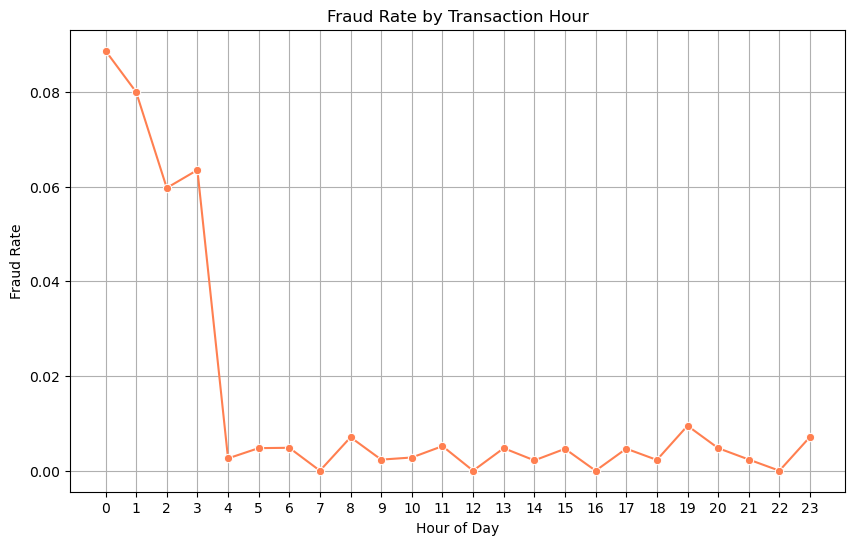


Transaction Volume by Hour of Day:


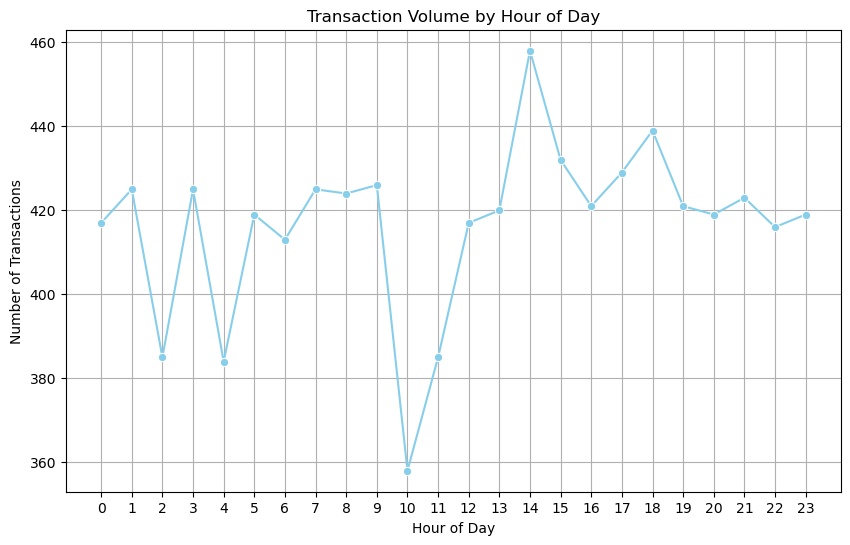

In [75]:
print("\nTemporal Pattern based on Transaction Hour:")
hourly_fraud = credit_data_df.groupby('transaction_hour')['is_fraud'].mean()
plt.figure(figsize=(10, 6))
sns.lineplot(
    x=hourly_fraud.index, 
    y=hourly_fraud.values, 
    marker='o', 
    color='coral'
    )
plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

print("\nTransaction Volume by Hour of Day:")
hourly_volume = credit_data_df.groupby('transaction_hour').size()
plt.figure(figsize=(10, 6))
sns.lineplot(
    x=hourly_volume.index, 
    y=hourly_volume.values, 
    marker='o', 
    color='skyblue'
    )
plt.title('Transaction Volume by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()



### Amount Analysis Deep Dive


Histogram of Amount Feature (using amount quantiles):


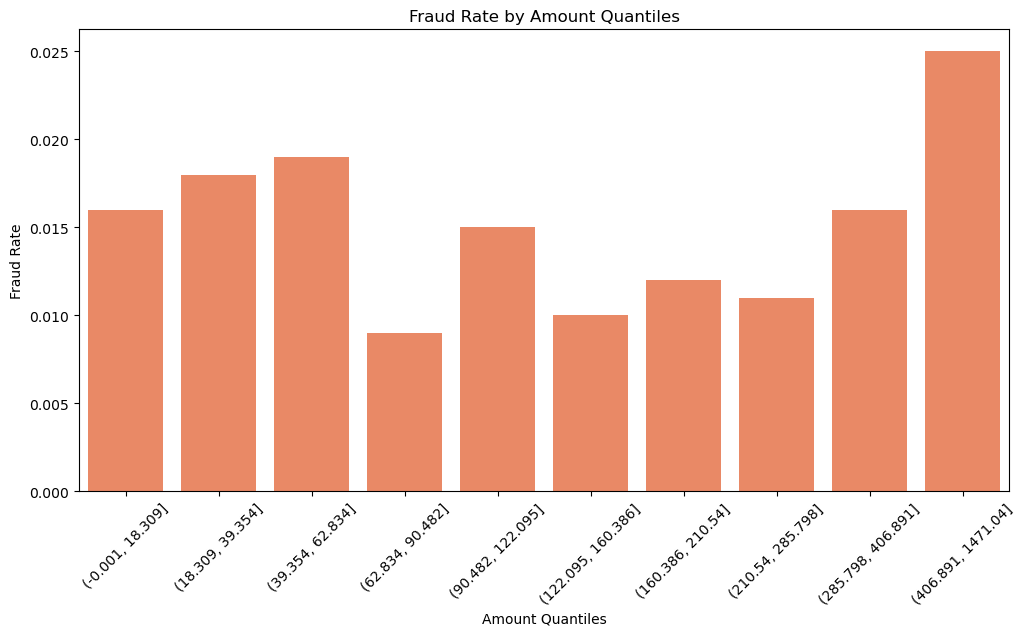

In [76]:
print("\nHistogram of Amount Feature (using amount quantiles):")
credit_data_df['amount_bin'] = pd.qcut(credit_data_df['amount'], q=10)
amount_fraud_rate = credit_data_df.groupby('amount_bin')['is_fraud'].mean()
plt.figure(figsize=(12, 6))
sns.barplot(
    x=amount_fraud_rate.index.astype(str), 
    y=amount_fraud_rate.values, 
    color='coral'
    )
plt.title('Fraud Rate by Amount Quantiles')
plt.xlabel('Amount Quantiles')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.show()




### Velocity and Behavior Signals



Box Plot of Velocity last 24h vs Fraud Status:


C:\Users\ben10\AppData\Local\Temp\ipykernel_27468\256031402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


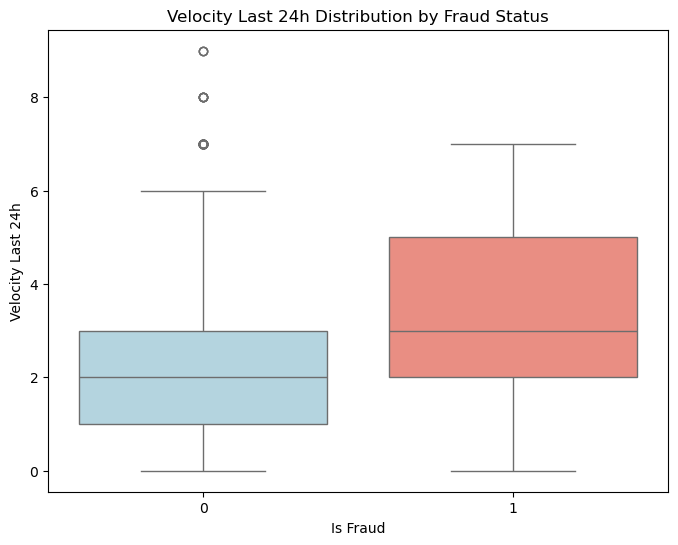

In [77]:
print("\nBox Plot of Velocity last 24h vs Fraud Status:")
plt.figure(figsize=(8, 6))
sns.boxplot(
    x='is_fraud', 
    y='velocity_last_24h', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon']
    )
plt.title('Velocity Last 24h Distribution by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Velocity Last 24h')
plt.show()

### Device Trust and Location Signals


Distribution of Device Trust Score by Fraud Status:


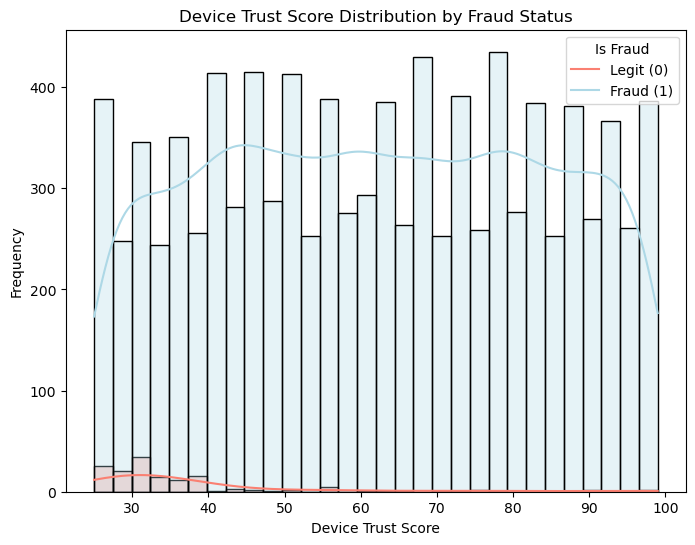


Cross Tabulation of Foreign Transaction vs Location Mismatch:


location_mismatch,0,1
foreign_transaction,,
0,8250,772
1,893,85


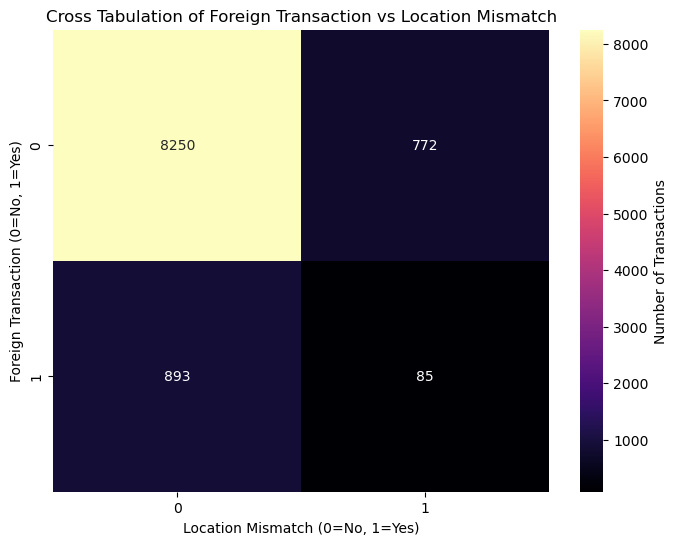

In [78]:
print("\nDistribution of Device Trust Score by Fraud Status:")
plt.figure(figsize=(8, 6))
sns.histplot(
    data=credit_data_df, 
    x='device_trust_score', 
    hue='is_fraud', 
    bins=30, 
    kde=True,
    palette=['lightblue', 'salmon'], 
    edgecolor='black', 
    alpha=0.3
    )
plt.title('Device Trust Score Distribution by Fraud Status')
plt.xlabel('Device Trust Score')
plt.ylabel('Frequency')
plt.legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
plt.show()

print("\nCross Tabulation of Foreign Transaction vs Location Mismatch:")
crosstab = pd.crosstab(
                credit_data_df['foreign_transaction'], 
                credit_data_df['location_mismatch']
                )
display(crosstab)
plt.figure(figsize=(8, 6))
sns.heatmap(
    crosstab, 
    annot=True, 
    fmt='d', 
    cmap='magma', 
    cbar_kws={'label': 'Number of Transactions'}
    )
plt.title('Cross Tabulation of Foreign Transaction vs Location Mismatch')
plt.xlabel('Location Mismatch (0=No, 1=Yes)')
plt.ylabel('Foreign Transaction (0=No, 1=Yes)')
plt.show()


### Demographic Insight (Age)


Demographic Analysis (Age Distribution by Fraud Status):


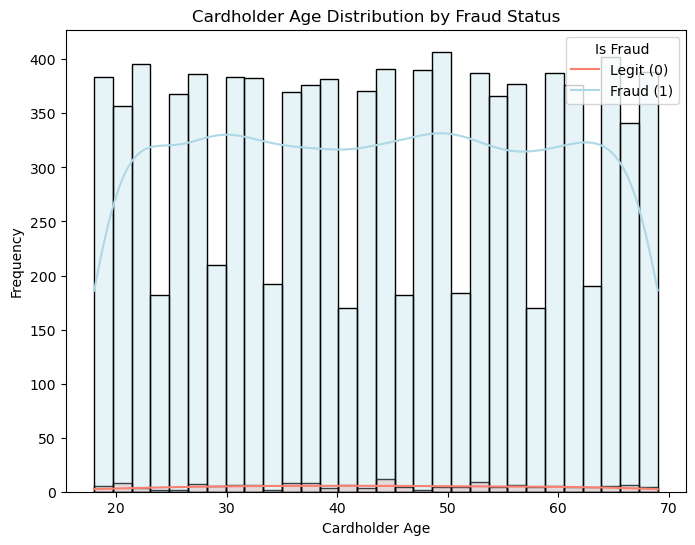

In [79]:
print("\nDemographic Analysis (Age Distribution by Fraud Status):")
plt.figure(figsize=(8, 6))
sns.histplot(
    data=credit_data_df, 
    x='cardholder_age', 
    hue='is_fraud', 
    bins=30, 
    kde=True,
    palette=['lightblue', 'salmon'], 
    edgecolor='black', 
    alpha=0.3
    )
plt.title('Cardholder Age Distribution by Fraud Status')
plt.xlabel('Cardholder Age')    
plt.ylabel('Frequency')
plt.legend(title='Is Fraud', labels=['Legit (0)', 'Fraud (1)'])
plt.show()

### Interaction Exploration 


Interaction between Amount and Device Trust Score by Fraud Status:


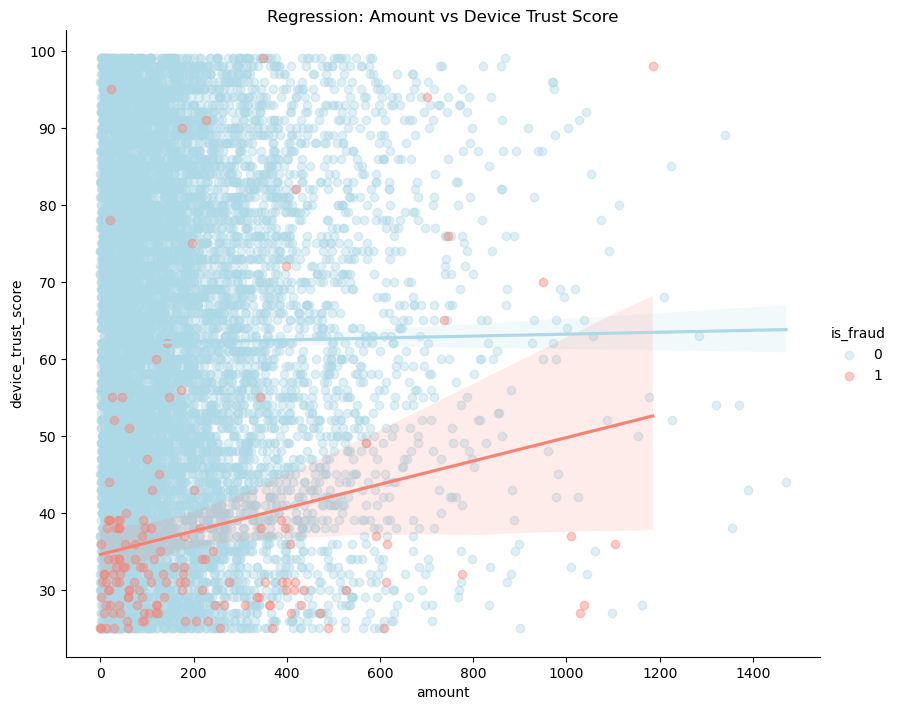


Interacton between merchant category and forein transaction by fraud status:


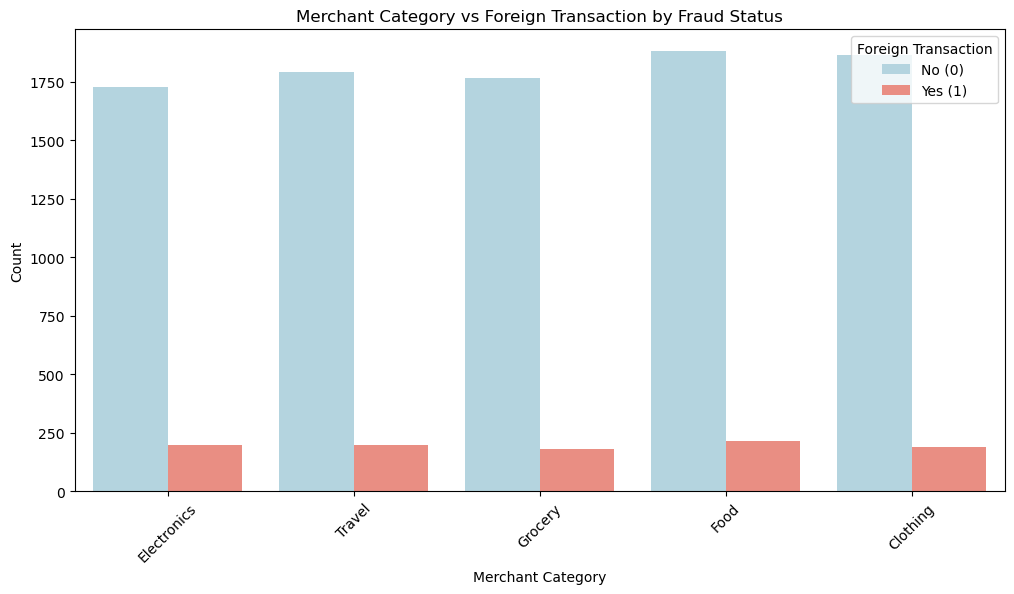


Interaction between transaction hour and location mismatch by fraud status:


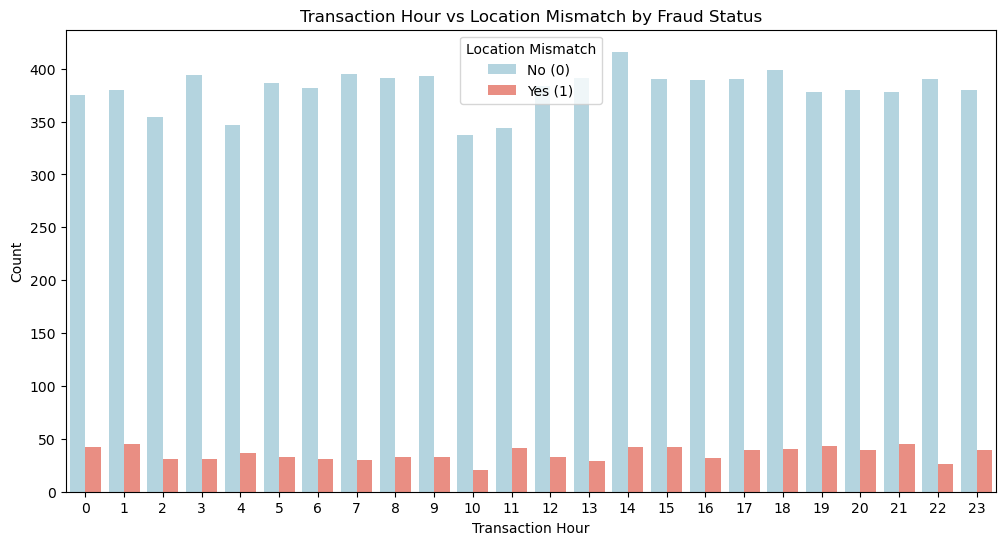


Interaction between transaction hour and velocity last 24h by fraud status:


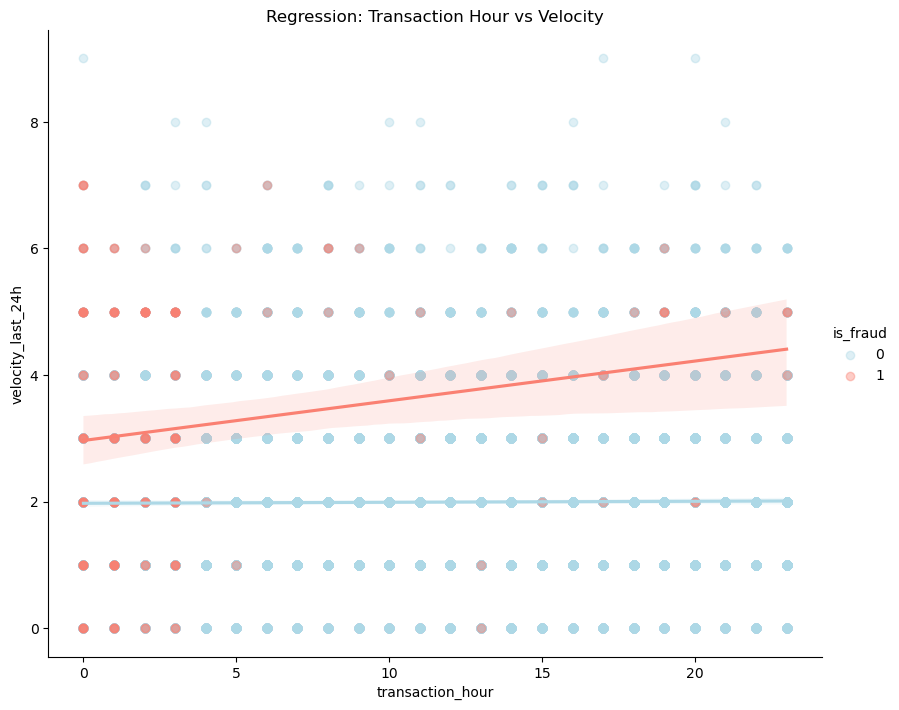


Interaction between cardholder age and velocity by fraud status:


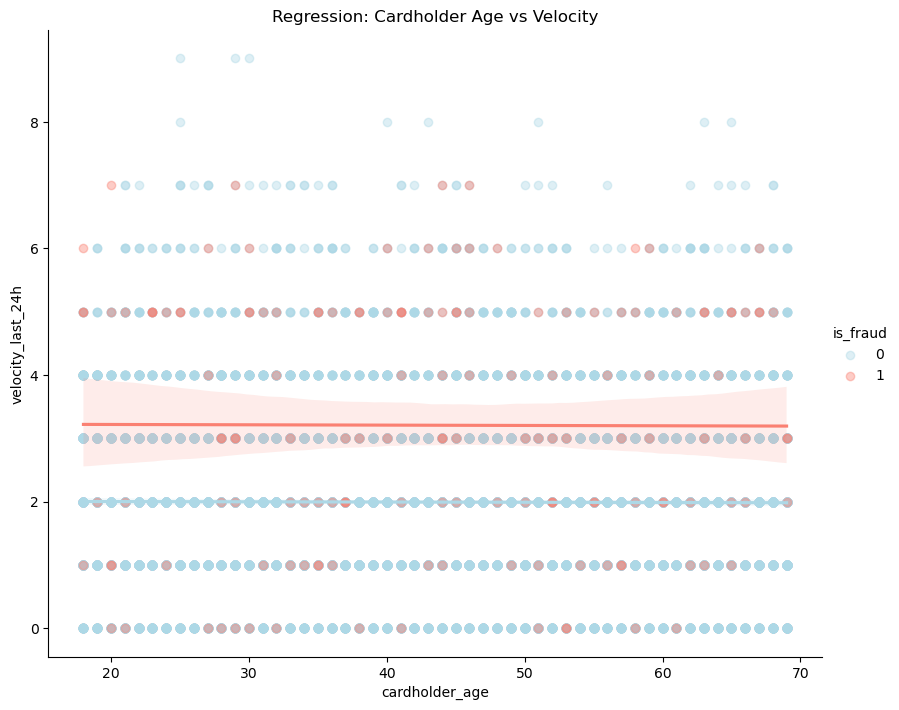


Interaction between location mismatch and foreign transaction by fraud status:


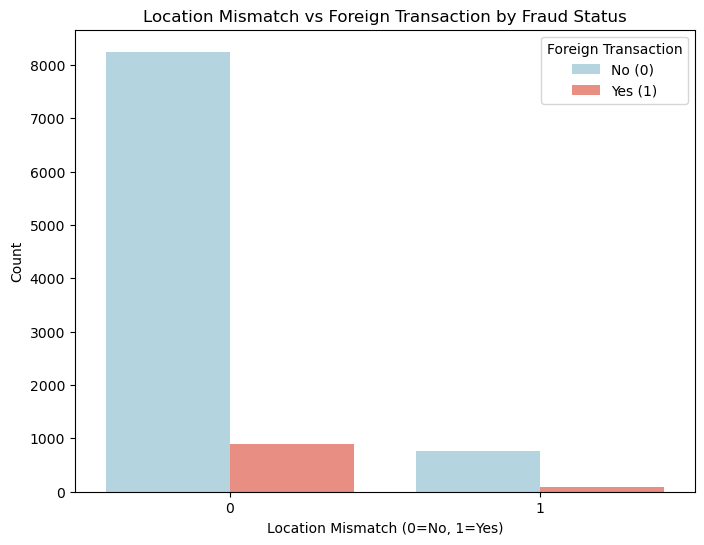


Interaction between amount and foreign transaction by fraud status:


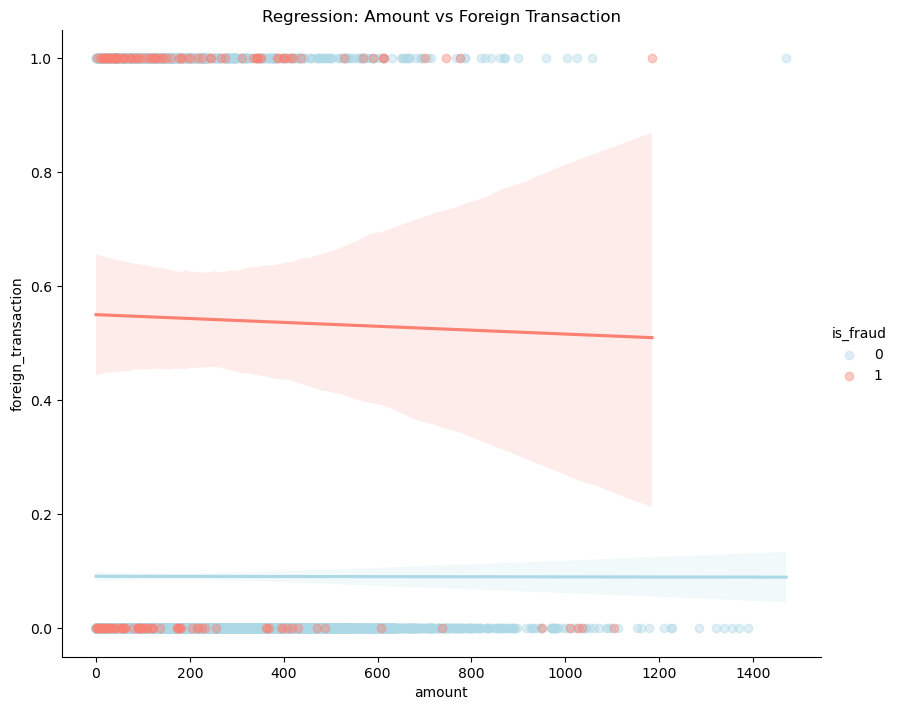

In [80]:
print("\nInteraction between Amount and Device Trust Score by Fraud Status:")
sns.lmplot(
    x='amount', 
    y='device_trust_score', 
    hue='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon'], 
    scatter_kws={'alpha':0.4},
    height=7, aspect=1.2
)
plt.title('Regression: Amount vs Device Trust Score')
plt.show()

print("\nInteracton between merchant category and forein transaction by fraud status:")
plt.figure(figsize=(12, 6))
sns.countplot(
    x='merchant_category', 
    hue='foreign_transaction', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon']
    )
plt.title('Merchant Category vs Foreign Transaction by Fraud Status')
plt.xlabel('Merchant Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Foreign Transaction', labels=['No (0)', 'Yes (1)'])
plt.show()

print("\nInteraction between transaction hour and location mismatch by fraud status:")
plt.figure(figsize=(12, 6))
sns.countplot(
    x='transaction_hour', 
    hue='location_mismatch', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon']
    )
plt.title('Transaction Hour vs Location Mismatch by Fraud Status')
plt.xlabel('Transaction Hour')
plt.ylabel('Count')
plt.xticks(range(0, 24))
plt.legend(title='Location Mismatch', labels=['No (0)', 'Yes (1)'])
plt.show()

print("\nInteraction between transaction hour and velocity last 24h by fraud status:")
sns.lmplot(
    x='transaction_hour', 
    y='velocity_last_24h', 
    hue='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon'], 
    scatter_kws={'alpha':0.4},
    height=7, aspect=1.2
)
plt.title('Regression: Transaction Hour vs Velocity')
plt.show()


print("\nInteraction between cardholder age and velocity by fraud status:")
sns.lmplot(
    x='cardholder_age', 
    y='velocity_last_24h', 
    hue='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon'], 
    scatter_kws={'alpha':0.4},
    height=7, aspect=1.2
)
plt.title('Regression: Cardholder Age vs Velocity')
plt.show()

print("\nInteraction between location mismatch and foreign transaction by fraud status:")
plt.figure(figsize=(8, 6))
sns.countplot(
    x='location_mismatch', 
    hue='foreign_transaction', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon']
    )
plt.title('Location Mismatch vs Foreign Transaction by Fraud Status')
plt.xlabel('Location Mismatch (0=No, 1=Yes)')
plt.ylabel('Count')
plt.legend(title='Foreign Transaction', labels=['No (0)', 'Yes (1)'])
plt.show()

print("\nInteraction between amount and foreign transaction by fraud status:")
sns.lmplot(
    x='amount', 
    y='foreign_transaction', 
    hue='is_fraud', 
    data=credit_data_df, 
    palette=['lightblue', 'salmon'], 
    scatter_kws={'alpha':0.4},
    height=7, aspect=1.2
)
plt.title('Regression: Amount vs Foreign Transaction')
plt.show()


## EDA Summary & Hypotheses
---
### **Key Findings**

- **Target Imbalance:** The dataset is highly imbalanced, with legitimate transactions significantly outnumbering fraud, as seen in the "blue soup" effect across all scatter, parallel coordinates and other plots.

- **Non-Linearity:** Individual numerical features show near-zero linear correlation with each other and with the fraud status, suggesting that simple linear models may struggle.

- **Temporal Burst Pattern:** Fraudulent transactions exhibit a "burst" behavior where velocity increases significantly during late-night hours, a trend not present in legitimate spending.

- **Geographic Risk:** A massive discrepancy exists in fraud rates based on location; over 50% of fraudulent transactions are foreign, compared to only ~10% of legitimate ones.

- **Device Trust Divergence:** Fraudulent transactions show a positive correlation between transaction amount and device trust, suggesting high-value fraud often involves sophisticated account or device hijacking.

---
### **Most Predictive Features (Potential "Signals")**

1. `foreign_transaction`: Shows the largest vertical separation between classes in regression analysis.

2. `velocity_last_24h`: Especially when interacting with transaction_hour.

3. `device_trust_score`: Particularly significant when analyzed alongside amount.

4. `location_mismatch`: High frequency of occurrence in fraud cases compared to the baseline.

---
### **Preprocessing & Data Issues to Fix**

- **Feature Scaling:** Parallel coordinates plots showed that amount (0–1500) dominates smaller-scale features like velocity (0–10). Min-Max scaling or Standardization is required.

- **Class Imbalance:** To prevent the model from simply "guessing" Legit every time, we must implement oversampling (SMOTE) or undersampling strategies.

- **Log Transformation:** The amount feature is heavily right-skewed; a log transformation is necessary to normalize the distribution for the model.

---
### **Proposed Feature Engineering**

1. **Temporal & Behavioral Indicators**
    - `is_night_transaction`: This will be a boolean flag for transactions occurring between 12 AM and 5 AM. Our regression analysis of `transaction_hour` vs `velocity_last_24h` showed a specific "burst" pattern at night.
    
    - `velocity_per_hour`: Since velocity is currently a 24-hour total, creating a ratio of `velocity_last_24h` / (`transaction_hour` + 1) might help identify sudden spikes in activity relative to the time of day.

    - `is_high_velocity_low_trust`: The bubble chart showed a cluster of fraud at high velocity and low trust. So we need to create a boolean flag: (`velocity_last_24h` > threshold) & (`device_trust_score` < threshold). Threshold needs to be a prenctile in order to avoid being too rigid in case velocity changed later so that it becomes self adjusting.

2. **Transactional & Geographic Complexity**
    - `high_risk_abroad`: The regression of `amount` vs `foreign_transaction` showed that fraud is significantly higher in foreign markets regardless of price. A combined flag `foreign_transaction` * `location_mismatch` would highlight the "Double-Mismatch" scenario.

    - `relative_amount`: Since the parallel coordinates plot showed `amount` is on a much larger scale than other features, creating a feature like `amount` / `average_merchant_category_amount` can show if a purchase is "out of character" for that specific category. 
    where `average_merchant_category_amount` is calculated as the **mean transaction amount for each specific merchant category** across the entire training dataset. This acts as a "behavioral baseline" allowing the model to detect when a transaction deviates significantly from the norm for that specific type of business.

3. **Mathematical Transformation**
    - `log_amount`: There is a need for a log transformation due to the skewed distribution of transaction `amount` values. This should be a permanent new column for the model.

    - `trust_score_binned`: Our regression showed that the relationship between `amount` and `device_trust_score` changes for fraud. Binning the trust score into "Low," "Medium," and "High" (Ordinal Encoding) might help a decision tree find better split points.